# Football Matches Dataset — EDA

**Dataset:** `scraped_dataset.csv`  
**Records:** ~16,688 matches | **Features:** 109 columns  
**Coverage:** Multiple leagues, seasons 2024-2026

---
### Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Missing Data Analysis](#3-missing)
3.5. [Outlier Check](#3-outliers)
4. [League & Season Distribution](#4-leagues)
5. [Match Outcomes & Scoring](#5-outcomes)
6. [Home Advantage Analysis](#6-home)
7. [Shooting & xG Analysis](#7-xg)
8. [Possession & Passing](#8-possession)
9. [Discipline (Cards & Fouls)](#9-discipline)
10. [Team Formations](#10.-Team-Formations)
11. [Correlation Heatmap](#11-correlation)
12. [Top Teams Analysis](#12-teams)

## 1. Setup & Data Loading <a id='1-setup'></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
ACCENT  = '#2E86AB'
ACCENT2 = '#E84855'
ACCENT3 = '#3BB273'
PALETTE = [ACCENT, ACCENT2, ACCENT3, '#F4A261', '#9B5DE5', '#FEE440']

In [ ]:
df = pd.read_csv("scraped_dataset.csv", low_memory=False)

df.head()

,match_id,league_division,season,round,date,kickoff_time,attendance,capacity,stadium,city,...,home_xg,away_xg,home_xgot,away_xgot,home_xa,away_xa,home_xgot_faced,away_xgot_faced,home_goals_prevented,away_goals_prevented
0,Ghrg3y4k,CAF Champions League,2024-2025,Semi-finals,"August 24, 2024",05:00 PM,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KMdN8ctS,CAF Champions League,2024-2025,Semi-finals,"August 17, 2024",04:00 PM,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8dbp3ZfU,CAF Champions League,2024-2025,Quarter-finals,"April 01, 2025",09:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,...,0.77,0.16,1.29,0.19,1.10,0.16,0.19,1.29,0.19,0.29
3,bLwfNxtn,CAF Champions League,2024-2025,Quarter-finals,"April 08, 2025",09:00 PM,NaN,35000.0,Al Hilal Stadium,Omdurman,...,0.36,0.91,0.26,0.80,0.81,0.72,0.80,0.26,-0.10,0.26
4,SrKJtrZj,CAF Champions League,2024-2025,3,"December 22, 2024",06:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Dataset Overview <a id='2-overview'></a>

In [ ]:
print('=== Basic Info ===')
print(f'Rows      : {len(df):,}')
print(f'Columns   : {df.shape[1]}')
print(f'Leagues   : {df["league_division"].nunique()}')
print(f'Teams     : {pd.concat([df["home_team"],df["away_team"]]).nunique()}')
seasons = sorted(df["season"].dropna().astype(str).str.strip().unique())
print(f'Seasons   : {seasons}')

=== Basic Info ===
Rows      : 16,688
Columns   : 109
Leagues   : 55
Teams     : 1353
Seasons   : ['2024-2025', '2025', '2025-2026', '2026']


Columns

In [ ]:
print(f"Dataset has {len(df.columns)} columns:\n")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

Dataset has 109 columns:

  1. match_id
  2. league_division
  3. season
  4. round
  5. date
  6. kickoff_time
  7. attendance
  8. capacity
  9. stadium
 10. city
 11. home_team
 12. away_team
 13. home_goals
 14. away_goals
 15. result
 16. home_formation
 17. away_formation
 18. home_team_rating
 19. away_team_rating
 20. home_shots_total
 21. away_shots_total
 22. home_shots_on_target
 23. away_shots_on_target
 24. home_shots_off_target
 25. away_shots_off_target
 26. home_shots_inside_box
 27. away_shots_inside_box
 28. home_shots_outside_box
 29. away_shots_outside_box
 30. home_headed_goals
 31. away_headed_goals
 32. home_hit_woodwork
 33. away_hit_woodwork
 34. home_corners
 35. away_corners
 36. home_free_kicks
 37. away_free_kicks
 38. home_throw_ins
 39. away_throw_ins
 40. home_fouls_committed
 41. away_fouls_committed
 42. home_offsides
 43. away_offsides
 44. home_yellow_cards
 45. away_yellow_cards
 46. home_red_cards
 47. away_red_cards
 48. home_goalkeeper_saves
 49.

Column Types

In [ ]:
print('=== Column Types ===')
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

=== Column Types ===
match_id: str
league_division: str
season: str
round: str
date: str
kickoff_time: str
attendance: float64
capacity: float64
stadium: str
city: str
home_team: str
away_team: str
home_goals: float64
away_goals: float64
result: str
home_formation: str
away_formation: str
home_team_rating: float64
away_team_rating: float64
home_shots_total: float64
away_shots_total: float64
home_shots_on_target: float64
away_shots_on_target: float64
home_shots_off_target: float64
away_shots_off_target: float64
home_shots_inside_box: float64
away_shots_inside_box: float64
home_shots_outside_box: float64
away_shots_outside_box: float64
home_headed_goals: float64
away_headed_goals: float64
home_hit_woodwork: float64
away_hit_woodwork: float64
home_corners: float64
away_corners: float64
home_free_kicks: float64
away_free_kicks: float64
home_throw_ins: float64
away_throw_ins: float64
home_fouls_committed: float64
away_fouls_committed: float64
home_offsides: float64
away_offsides: float64
ho

Dublicates

In [ ]:
print(f"Total rows: {len(df):,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
# No duplicates found, so we can proceed without dropping any rows.


Total rows: 16,688
Duplicate rows: 0


 Basic cleaning and Feature Engineering

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['total_goals']   = df['home_goals'] + df['away_goals']
df['goal_diff']     = df['home_goals'] - df['away_goals']
df['total_shots']   = df['home_shots_total'].fillna(0) + df['away_shots_total'].fillna(0)
df['total_xg']      = df['home_xg'].fillna(0) + df['away_xg'].fillna(0)

print(f'Shape : {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Shape : (16688, 113)
Date range: 2023-09-08 → 2026-04-14


,match_id,league_division,season,round,date,kickoff_time,attendance,capacity,stadium,city,...,home_xa,away_xa,home_xgot_faced,away_xgot_faced,home_goals_prevented,away_goals_prevented,total_goals,goal_diff,total_shots,total_xg
0,Ghrg3y4k,CAF Champions League,2024-2025,Semi-finals,2024-08-24,05:00 PM,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,0.0,0.00
1,KMdN8ctS,CAF Champions League,2024-2025,Semi-finals,2024-08-17,04:00 PM,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.00
2,8dbp3ZfU,CAF Champions League,2024-2025,Quarter-finals,2025-04-01,09:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,...,1.10,0.16,0.19,1.29,0.19,0.29,1.0,1.0,18.0,0.93
3,bLwfNxtn,CAF Champions League,2024-2025,Quarter-finals,2025-04-08,09:00 PM,NaN,35000.0,Al Hilal Stadium,Omdurman,...,0.81,0.72,0.80,0.26,-0.10,0.26,1.0,-1.0,19.0,1.27
4,SrKJtrZj,CAF Champions League,2024-2025,3,2024-12-22,06:00 PM,NaN,30000.0,Al Salam Stadium,Cairo,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,5.0,27.0,0.00


Numeric Summary

In [ ]:
print('=== Numeric Summary ===')
cols = ['home_goals','away_goals','total_goals','home_xg','away_xg',
        'home_possession_pct','home_shots_total','away_shots_total']
df[cols].describe().round(2)

=== Numeric Summary ===


,home_goals,away_goals,total_goals,home_xg,away_xg,home_possession_pct,home_shots_total,away_shots_total
count,16686.00,16686.00,16686.00,13408.00,13408.00,16226.00,16229.00,16229.00
mean,1.53,1.22,2.74,1.49,1.18,51.38,13.74,11.18
std,1.31,1.18,1.70,0.86,0.76,10.95,5.57,4.96
min,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,1.00,0.00,1.00,0.84,0.61,44.00,10.00,8.00
50%,1.00,1.00,3.00,1.36,1.04,52.00,13.00,11.00
75%,2.00,2.00,4.00,1.96,1.60,59.00,17.00,14.00
max,11.00,11.00,12.00,7.55,6.44,85.00,60.00,41.00


## 3. Missing Data Analysis <a id='3-missing'></a>

In [ ]:
# Complete missing value analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

# Create a summary DataFrame
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Pct': missing_pct,
    'Dtype': df.dtypes
})

# Sort by missing percentage
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Pct', ascending=False)

print("\n" + "="*55)
print("MISSING VALUE ANALYSIS")
print("="*55)
print(f"Total cells: {df.size:,}")
print(f"Missing cells: {df.isnull().sum().sum():,}")
print(f"Overall missing rate: {(df.isnull().sum().sum() / df.size * 100):.2f}%")
print(f"Complete columns: {(missing == 0).sum()}/{len(df.columns)}")
print(f"Columns with missing: {(missing > 0).sum()}/{len(df.columns)}")

# Show columns with missing values
if len(missing_df) > 0:
    print("\n" + "-"*55)
    print("Columns with missing values:")
    print("-"*55)
    for idx, row in missing_df.iterrows():
        status = "🔴" if row['Missing_Pct'] > 50 else "🟡" if row['Missing_Pct'] > 10 else "🟢"
        print(f"{status} {idx:<35} {row['Missing_Count']:>8,} ({row['Missing_Pct']:>6.2f}%) - {row['Dtype']}")
else:
    print("\n✓ No missing values found!")


MISSING VALUE ANALYSIS
Total cells: 1,885,744
Missing cells: 381,562
Overall missing rate: 20.23%
Complete columns: 10/113
Columns with missing: 103/113

-------------------------------------------------------
Columns with missing values:
-------------------------------------------------------
🔴 home_headed_goals                     12,248 ( 73.39%) - float64
🔴 away_headed_goals                     12,248 ( 73.39%) - float64
🟡 home_errors_leading_to_goal            7,385 ( 44.25%) - float64
🟡 away_errors_leading_to_goal            7,385 ( 44.25%) - float64
🟡 home_errors_leading_to_shot            7,367 ( 44.15%) - float64
🟡 away_errors_leading_to_shot            7,367 ( 44.15%) - float64
🟡 away_accurate_through_passes           7,351 ( 44.05%) - float64
🟡 home_accurate_through_passes           7,351 ( 44.05%) - float64
🟡 home_xgot_faced                        7,284 ( 43.65%) - float64
🟡 away_xgot_faced                        7,284 ( 43.65%) - float64
🟡 away_long_passes_total          

Check for inconsistencies between home and away data.

In [ ]:

row_match_results = []

for col in df.columns:
    if col.startswith('home_'):
        away_col = col.replace('home_', 'away_')

        if away_col in df.columns:

            same_missing = (
                df[col].isnull() == df[away_col].isnull()
            ).mean() * 100

            row_match_results.append({
                'Home Column': col,
                'Away Column': away_col,
                'Matching Missing Rows %': round(same_missing, 2)
            })

match_df = pd.DataFrame(row_match_results)

match_df.sort_values(
    'Matching Missing Rows %'
)

,Home Column,Away Column,Matching Missing Rows %
0,home_team,away_team,100.0
1,home_goals,away_goals,100.0
2,home_formation,away_formation,100.0
3,home_team_rating,away_team_rating,100.0
4,home_shots_total,away_shots_total,100.0
5,home_shots_on_target,away_shots_on_target,100.0
6,home_shots_off_target,away_shots_off_target,100.0
7,home_shots_inside_box,away_shots_inside_box,100.0
8,home_shots_outside_box,away_shots_outside_box,100.0
9,home_headed_goals,away_headed_goals,100.0


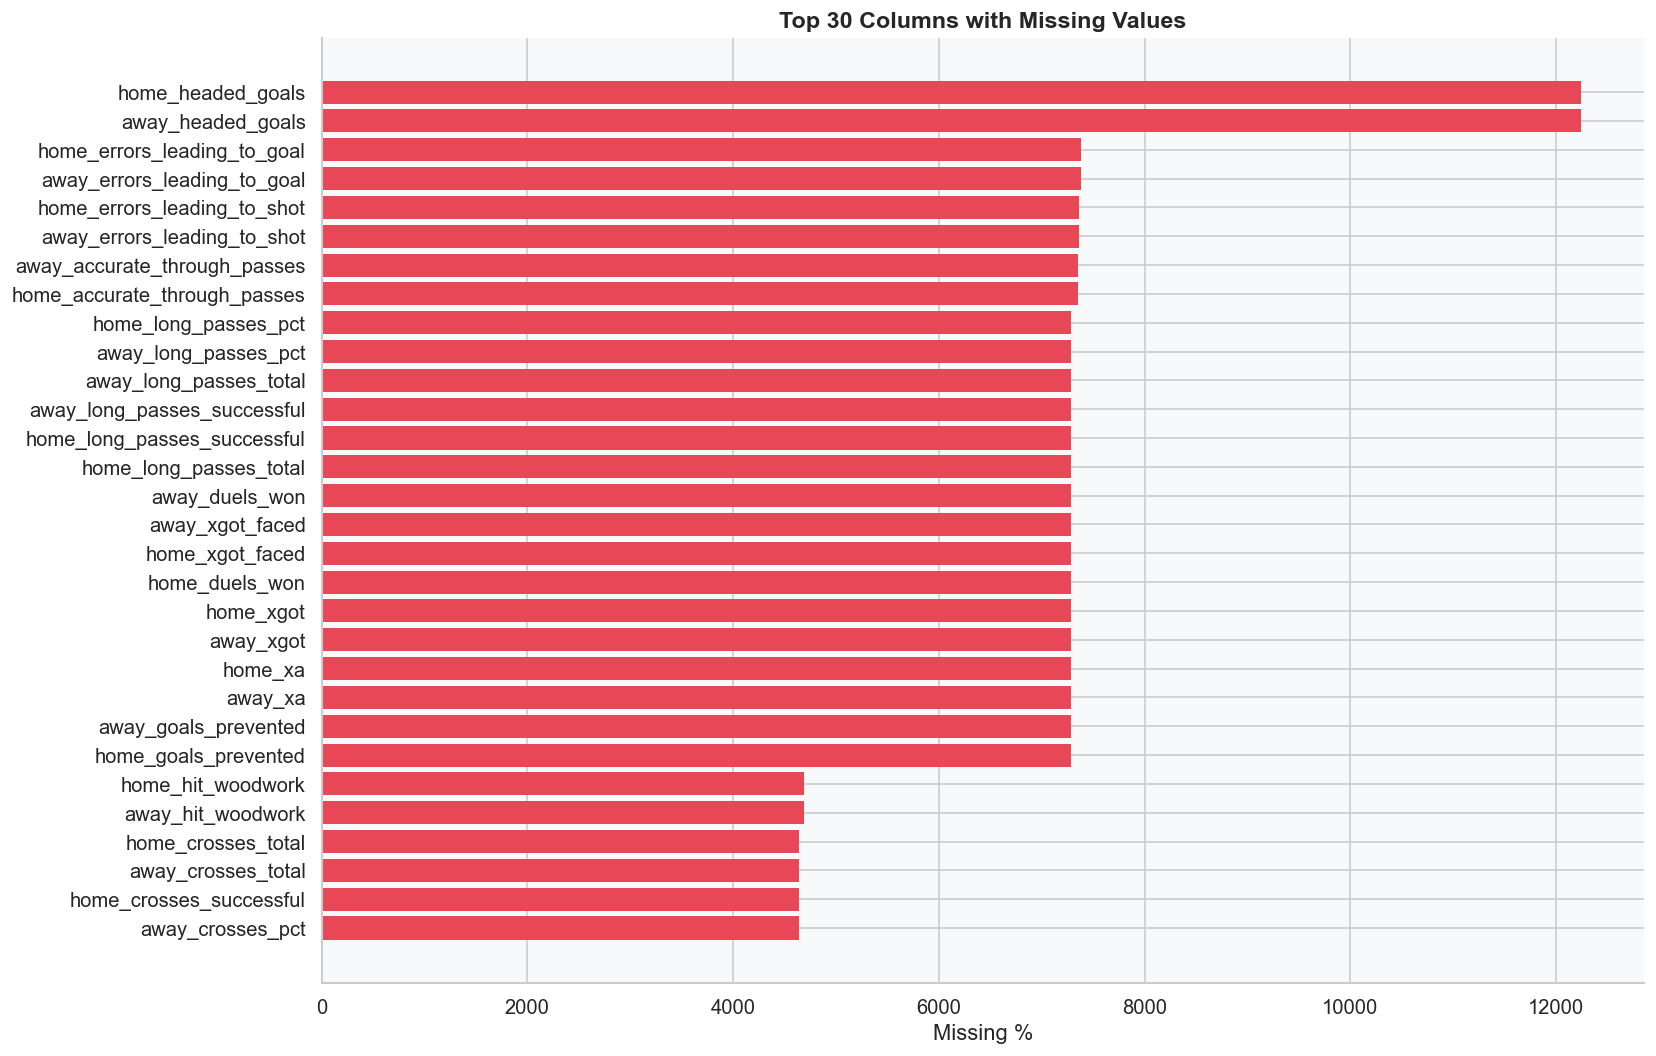

In [ ]:
# Only show columns with missing values
missing_sig = missing[missing > 0].sort_values(ascending=False)

# If still too many, filter further
if len(missing_sig) > 30:
    # Option A: Show top 30 most missing
    missing_sig = missing_sig.head(30)


fig, ax = plt.subplots(figsize=(14, max(8, len(missing_sig)*0.3)))
colors = [ACCENT2 if v > 50 else ACCENT for v in missing_sig.values]
ax.barh(missing_sig.index, missing_sig.values, color=colors, edgecolor='none')
ax.set_xlabel('Missing %')
ax.set_title(f'Top {len(missing_sig)} Columns with Missing Values', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Check why headed goals is largely missing

In [ ]:
print((df['home_headed_goals'] == 0).sum())
print((df['away_headed_goals'] == 0).sum())

both_zero = (
    (df['home_headed_goals'] == 0) &
    (df['away_headed_goals'] == 0)
)

print("Rows with both = 0:", both_zero.sum())


1650
2299
Rows with both = 0: 0


this means that during scraping in case both headed goals were zero it wasn't scraped   
almost always when features loke errorrs leading to goal and accuate through passes existed the headed goals existed   
frtom this we  can conclude that 

Missing Coulmns Percentages

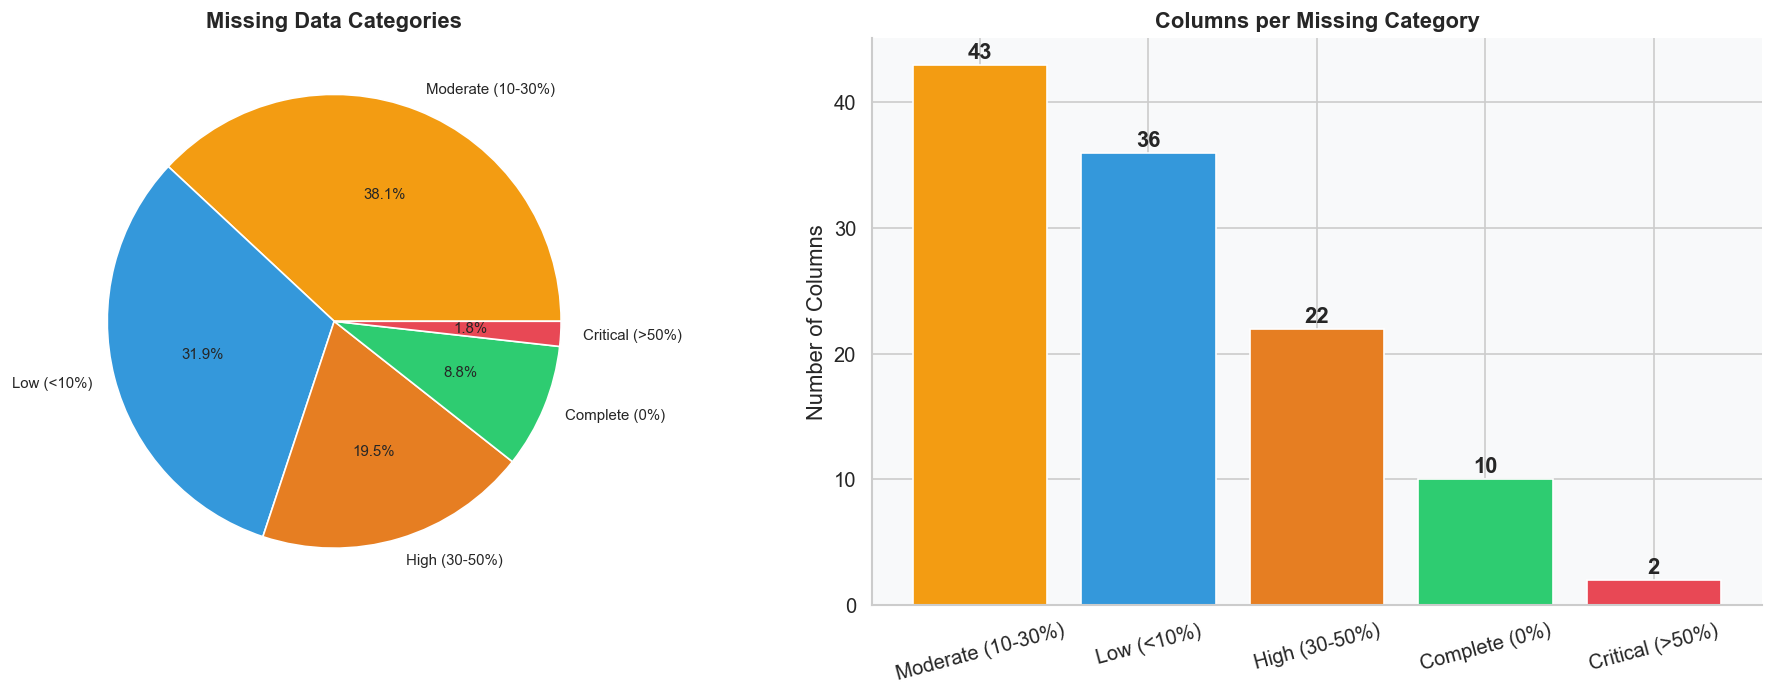

In [ ]:
missing_pct = (df.isnull().mean() * 100)

# Categorize columns by missing percentage
def categorize_missing(pct):
    if pct == 0:
        return 'Complete (0%)'
    elif pct < 10:
        return 'Low (<10%)'
    elif pct < 30:
        return 'Moderate (10-30%)'
    elif pct < 50:
        return 'High (30-50%)'
    else:
        return 'Critical (>50%)'

missing_categories = missing_pct.apply(categorize_missing)
cat_counts = missing_categories.value_counts()

# Create category summary
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_dict = {
    'Complete (0%)': '#2ECC71',
    'Low (<10%)': '#3498DB',
    'Moderate (10-30%)': '#F39C12',
    'High (30-50%)': '#E67E22',
    'Critical (>50%)': ACCENT2
}

cat_colors = [colors_dict[cat] for cat in cat_counts.index]

# Pie chart
wedges, texts, autotexts = ax1.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=cat_colors,
    textprops={'fontsize': 9}
)

ax1.set_title('Missing Data Categories', fontweight='bold')

# Bar chart
ax2.bar(cat_counts.index, cat_counts.values, color=cat_colors)
ax2.set_ylabel('Number of Columns')
ax2.set_title('Columns per Missing Category', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

for i, v in enumerate(cat_counts.values):
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Bar Plot for missing data per column

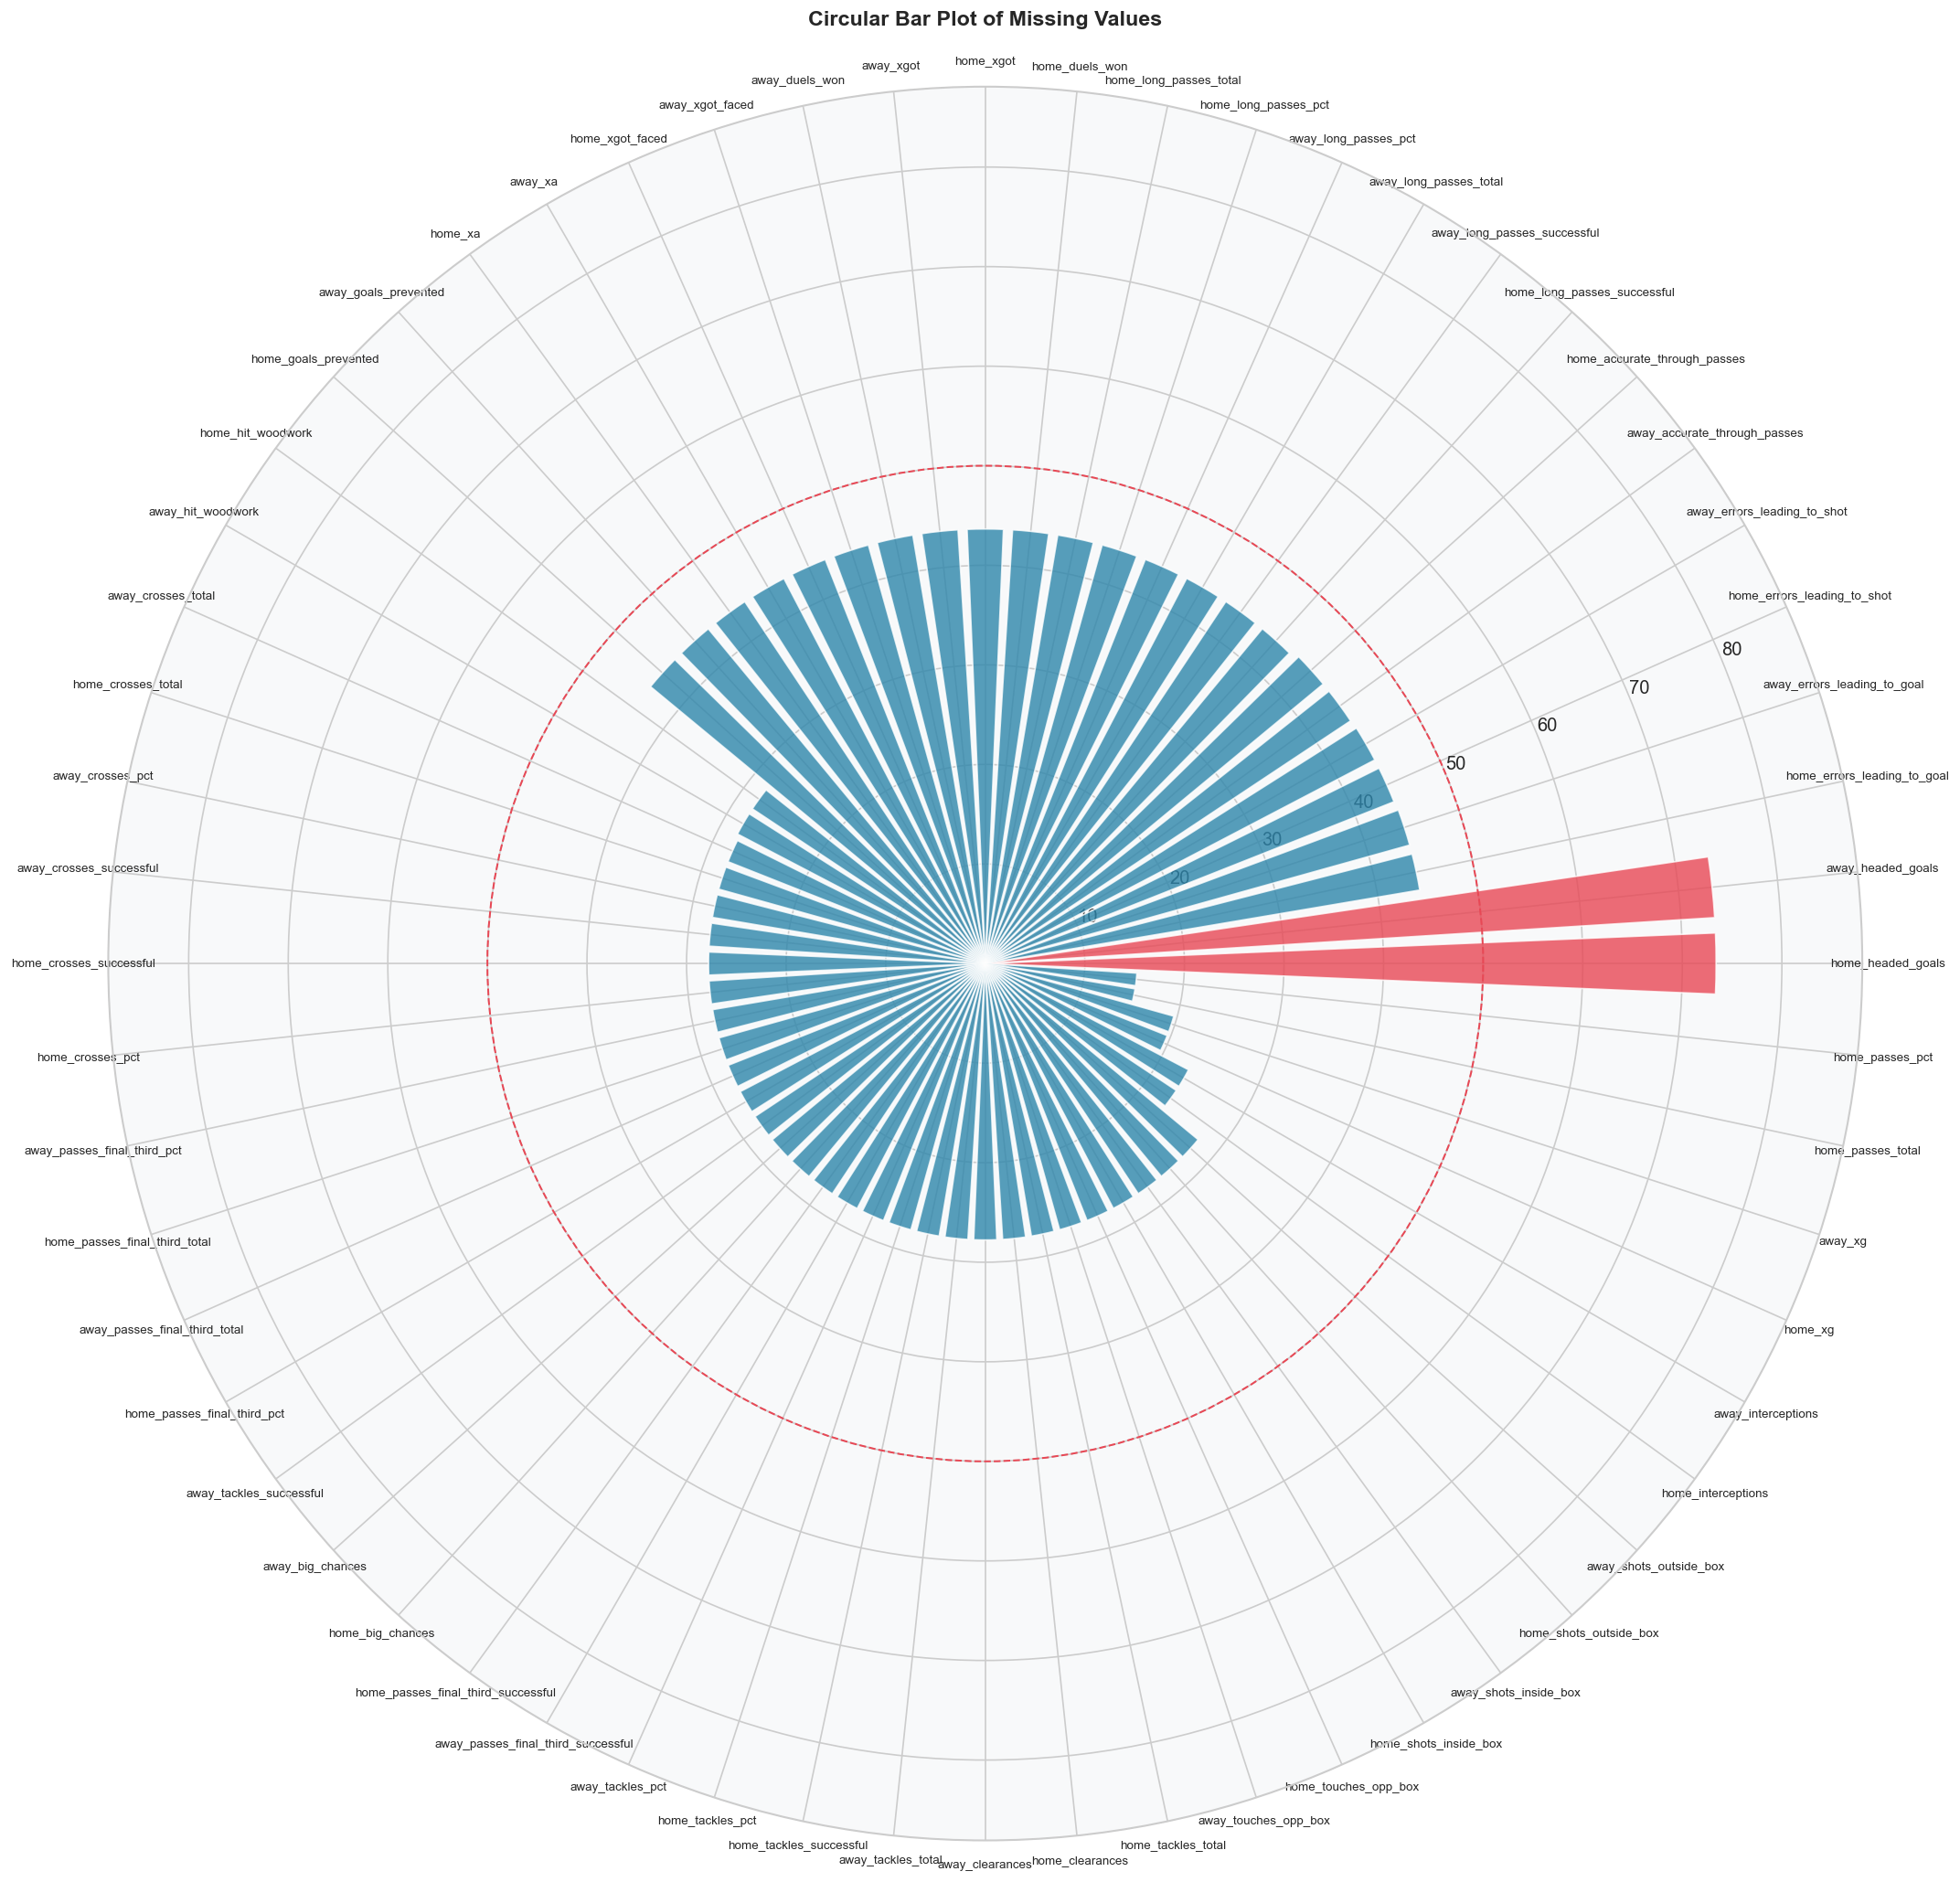

In [ ]:
# missing_sig = missing[missing > 0]
missing_sig = missing_pct.sort_values(ascending=False).head(60)
# Create circular bar plot
fig, ax = plt.subplots(figsize=(18, 18), subplot_kw={'projection': 'polar'})

angles = np.linspace(0, 2*np.pi, len(missing_sig), endpoint=False)
values = missing_sig.values
colors = [ACCENT2 if v > 50 else ACCENT for v in values]

bars = ax.bar(angles, values, width=2*np.pi/len(missing_sig)*0.8, 
              color=colors, alpha=0.8, edgecolor='white')

ax.set_xticks(angles)
ax.set_xticklabels(missing_sig.index, size=8)
ax.set_ylim(0, max(values) * 1.2)
ax.set_title('Circular Bar Plot of Missing Values', fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=50, color=ACCENT2, linestyle='--', linewidth=1.2)

plt.tight_layout()
plt.show()

Missing Rows

In [ ]:
print("Missing rows analysis:")
print(f"Total rows: {len(df)}")

print(f"Complete rows: {(df.isnull().sum(axis=1) == 0).sum()}")

print(f"Rows with at least 1 missing: {(df.isnull().sum(axis=1) > 0).sum()}")

print(f"Rows with >20% missing columns: {(df.isnull().sum(axis=1) > df.shape[1] * 0.2).sum()}")

print(f"Rows with >40% missing columns: {(df.isnull().sum(axis=1) > df.shape[1] * 0.4).sum()}")

print(f"Rows with >50% missing columns: {(df.isnull().sum(axis=1) > df.shape[1] * 0.5).sum()}")

print(f"Rows with >80% missing columns: {(df.isnull().sum(axis=1) > df.shape[1] * 0.8).sum()}")

print(f"Rows with >90% missing columns: {(df.isnull().sum(axis=1) > df.shape[1] * 0.9).sum()}")


Missing rows analysis:
Total rows: 16688
Complete rows: 2758
Rows with at least 1 missing: 13930
Rows with >20% missing columns: 6441
Rows with >40% missing columns: 4633
Rows with >50% missing columns: 3824
Rows with >80% missing columns: 426
Rows with >90% missing columns: 0


From this we can conclude that most of the rows has the full advanced features 

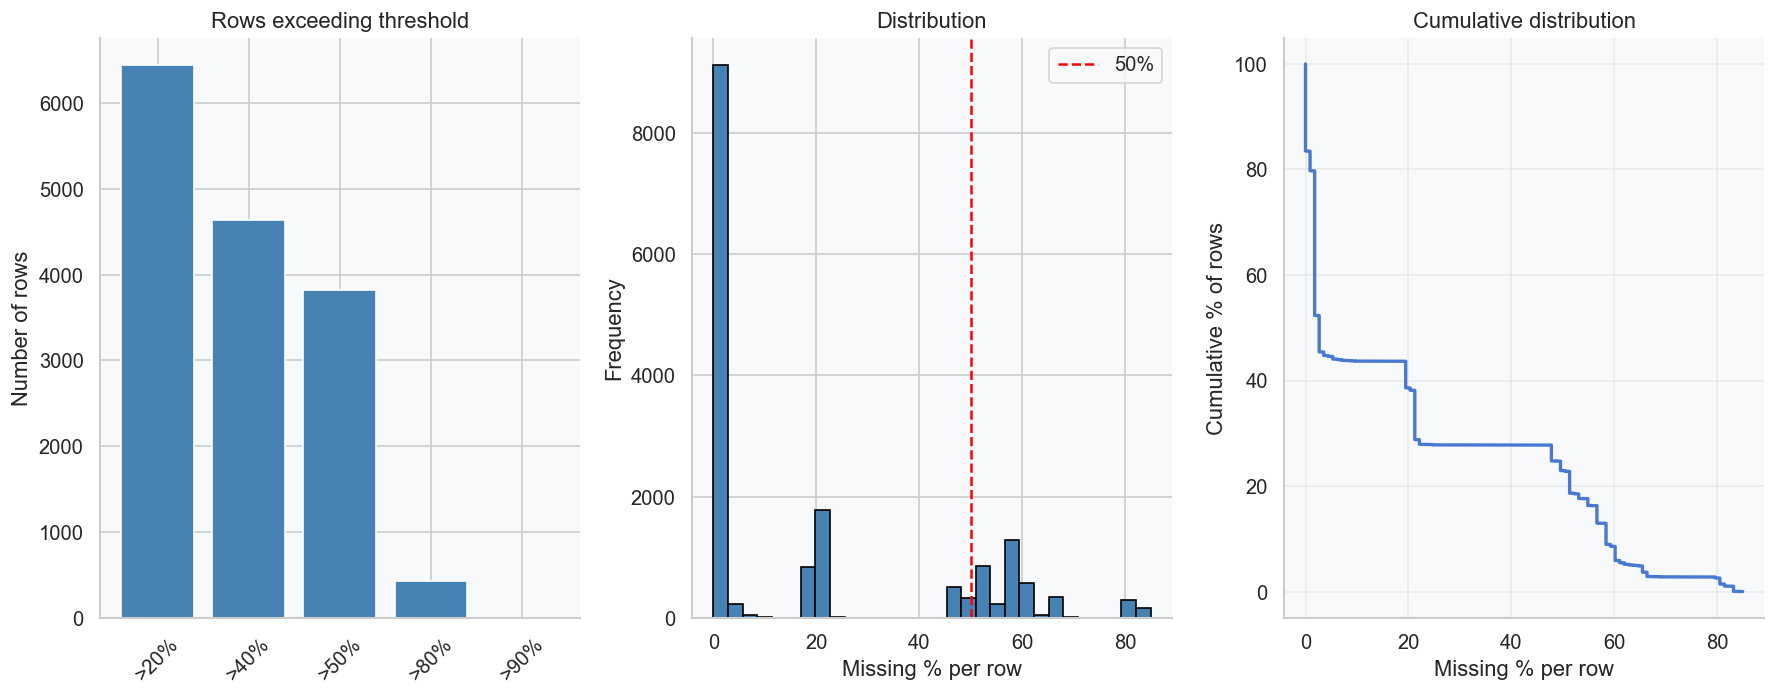

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))  

missing_per_row = df.isnull().sum(axis=1)
missing_percentage = (missing_per_row / df.shape[1]) * 100

# Plot 1: Bar chart
thresholds = [20, 40, 50, 80, 90]
counts = [(missing_percentage > t).sum() for t in thresholds]
axes[0].bar([f'>{t}%' for t in thresholds], counts, color='steelblue')  
axes[0].set_ylabel('Number of rows')
axes[0].set_title('Rows exceeding threshold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Histogram
axes[1].hist(missing_percentage, bins=30, color='steelblue', edgecolor='black')  
axes[1].axvline(50, color='red', linestyle='--', label='50%')
axes[1].set_xlabel('Missing % per row')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution')
axes[1].legend()

# Plot 3: Cumulative
sorted_pct = missing_percentage.sort_values(ascending=False)
cumulative_pct = np.arange(1, len(sorted_pct)+1) / len(sorted_pct) * 100
axes[2].plot(sorted_pct.values, cumulative_pct, linewidth=2)  
axes[2].set_xlabel('Missing % per row')
axes[2].set_ylabel('Cumulative % of rows')
axes[2].set_title('Cumulative distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.5 Outlier Check <a id='3-outliers'></a>

In [ ]:
# ── Outlier Detection: IQR Method ──────────────────────────────────────────
key_cols = [
    'home_goals', 'away_goals', 'total_goals',
    'home_xg', 'away_xg',
    'home_shots_total', 'away_shots_total',
    'home_possession_pct', 'away_possession_pct',
    'home_yellow_cards', 'away_yellow_cards',
    'home_fouls_committed', 'away_fouls_committed',
]
key_cols = [c for c in key_cols if c in df.columns]

outlier_summary = []

for col in key_cols:
    s = df[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_pct = n_outliers / len(s) * 100
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outlier Count': n_outliers,
        'Outlier %': round(outlier_pct, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print('=== IQR-Based Outlier Summary ===')
print(outlier_df.to_string(index=False))


In [ ]:
# ── Box Plots: Visualising Outliers ────────────────────────────────────────
plot_cols = [
    'total_goals', 'home_xg', 'away_xg',
    'home_shots_total', 'away_shots_total',
    'home_possession_pct',
    'home_yellow_cards', 'home_fouls_committed',
]
plot_cols = [c for c in plot_cols if c in df.columns]

n = len(plot_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    data = df[col].dropna()

    # Box plot with fliers
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=ACCENT, alpha=0.6),
                    medianprops=dict(color=ACCENT2, linewidth=2),
                    flierprops=dict(marker='o', color=ACCENT2,
                                    alpha=0.3, markersize=3))

    # Annotate median and IQR fence values
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR

    ax.axhline(upper_fence, color='red', linestyle='--', linewidth=1,
               label=f'Upper fence: {upper_fence:.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    ax.set_xticks([])
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Check — Box Plots (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ── Outlier Rate per Column & Extreme Match Examples ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart of outlier % per column
ax = axes[0]
od = outlier_df.sort_values('Outlier %', ascending=True)
colors_o = [ACCENT2 if v > 5 else ACCENT for v in od['Outlier %']]
ax.barh(od['Column'], od['Outlier %'], color=colors_o, edgecolor='none')
ax.axvline(5, color='gray', linestyle='--', linewidth=1.2, label='5% threshold')
ax.set_xlabel('Outlier %')
ax.set_title('Outlier Rate per Column (IQR ×1.5)', fontweight='bold')
ax.legend(fontsize=9)

# Right: Scatter of total_goals vs home_xg, highlighting outliers
ax = axes[1]
sub = df.dropna(subset=['total_goals', 'home_xg']).copy()
Q1 = sub['total_goals'].quantile(0.25)
Q3 = sub['total_goals'].quantile(0.75)
upper = Q3 + 1.5 * (Q3 - Q1)

is_outlier = sub['total_goals'] > upper
ax.scatter(sub.loc[~is_outlier, 'home_xg'], sub.loc[~is_outlier, 'total_goals'],
           alpha=0.2, s=12, color=ACCENT, label='Normal')
ax.scatter(sub.loc[is_outlier, 'home_xg'], sub.loc[is_outlier, 'total_goals'],
           alpha=0.6, s=25, color=ACCENT2, label=f'Outlier (goals > {upper:.0f})')
ax.set_xlabel('Home xG')
ax.set_ylabel('Total Goals')
ax.set_title('Total Goals vs Home xG — Outliers Highlighted', fontweight='bold')
ax.legend()

plt.suptitle('Outlier Analysis Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Show the most extreme matches
print("\n=== Top 10 Highest-Scoring Matches ===")
extreme = df.nlargest(10, 'total_goals')[
    ['date', 'league_division', 'home_team', 'away_team',
     'home_goals', 'away_goals', 'total_goals']
]
print(extreme.to_string(index=False))


## 4. League & Season Distribution <a id='4-leagues'></a>

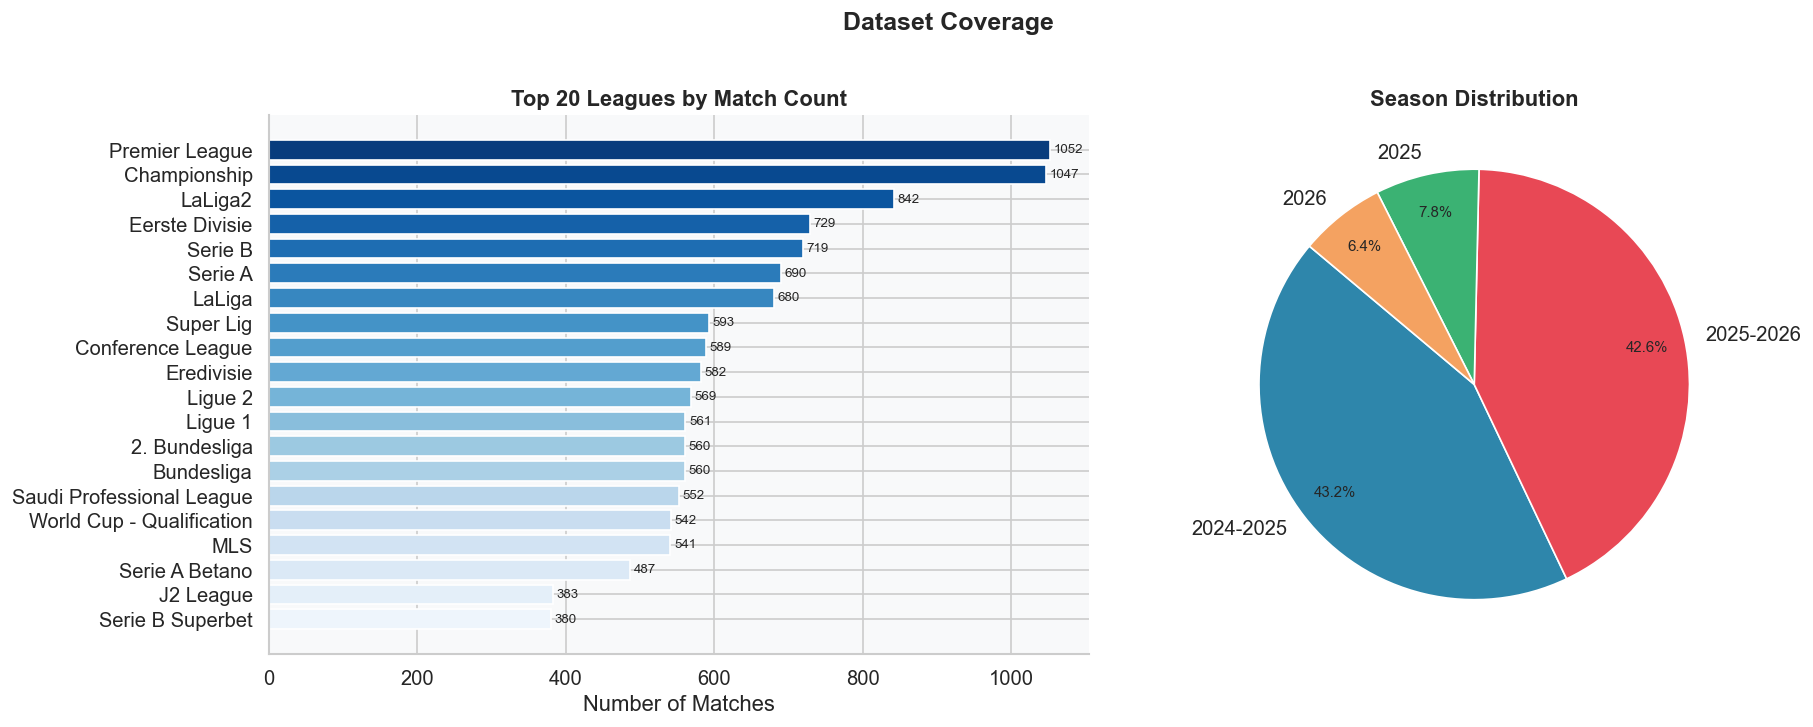

In [ ]:
top_leagues = df['league_division'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — top leagues
ax = axes[0]
colors_bar = sns.color_palette('Blues_r', len(top_leagues))
ax.barh(top_leagues.index[::-1], top_leagues.values[::-1], color=colors_bar[::-1])
ax.set_xlabel('Number of Matches')
ax.set_title('Top 20 Leagues by Match Count', fontweight='bold')
for i, v in enumerate(top_leagues.values[::-1]):
    ax.text(v + 5, i, str(v), va='center', fontsize=8)

# Pie — season breakdown
ax = axes[1]
season_counts = df['season'].value_counts()
wedges, texts, autotexts = ax.pie(
    season_counts.values, labels=season_counts.index,
    autopct='%1.1f%%', colors=PALETTE, startangle=140,
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Season Distribution', fontweight='bold')

plt.suptitle('Dataset Coverage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Matches distrpution over monthes

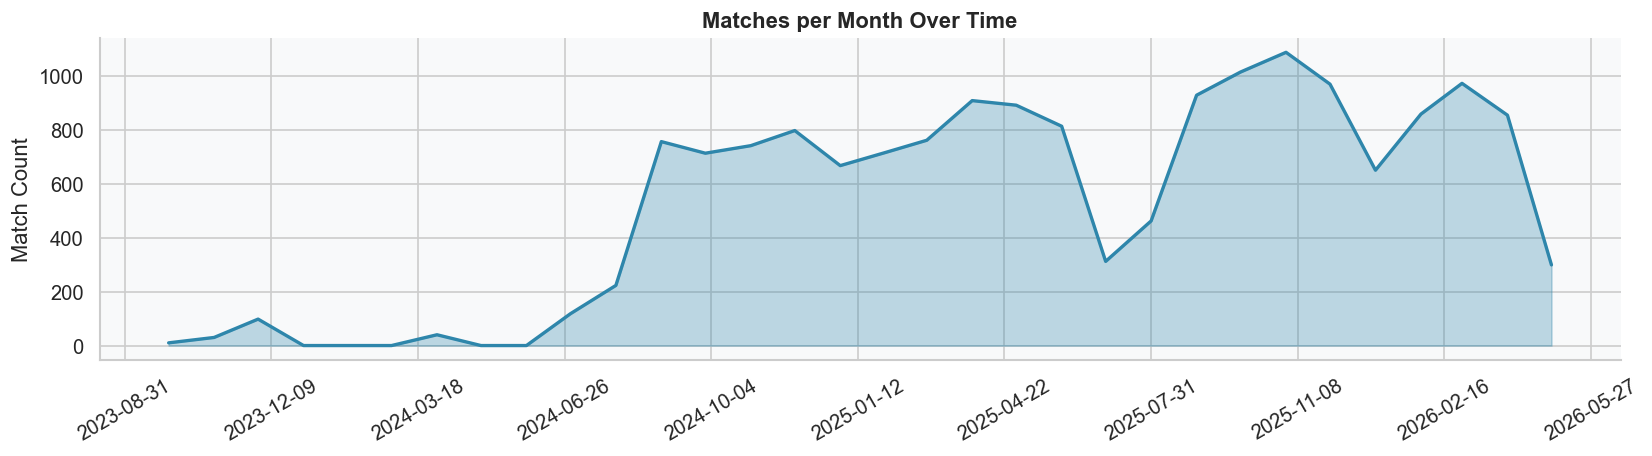

In [ ]:
# First convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Then resample
monthly = df.set_index('date').resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly.index, monthly.values, alpha=0.3, color=ACCENT)
ax.plot(monthly.index, monthly.values, color=ACCENT, linewidth=2)
ax.set_title('Matches per Month Over Time', fontweight='bold')
ax.set_ylabel('Match Count')
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Match Outcomes & Scoring <a id='5-outcomes'></a>

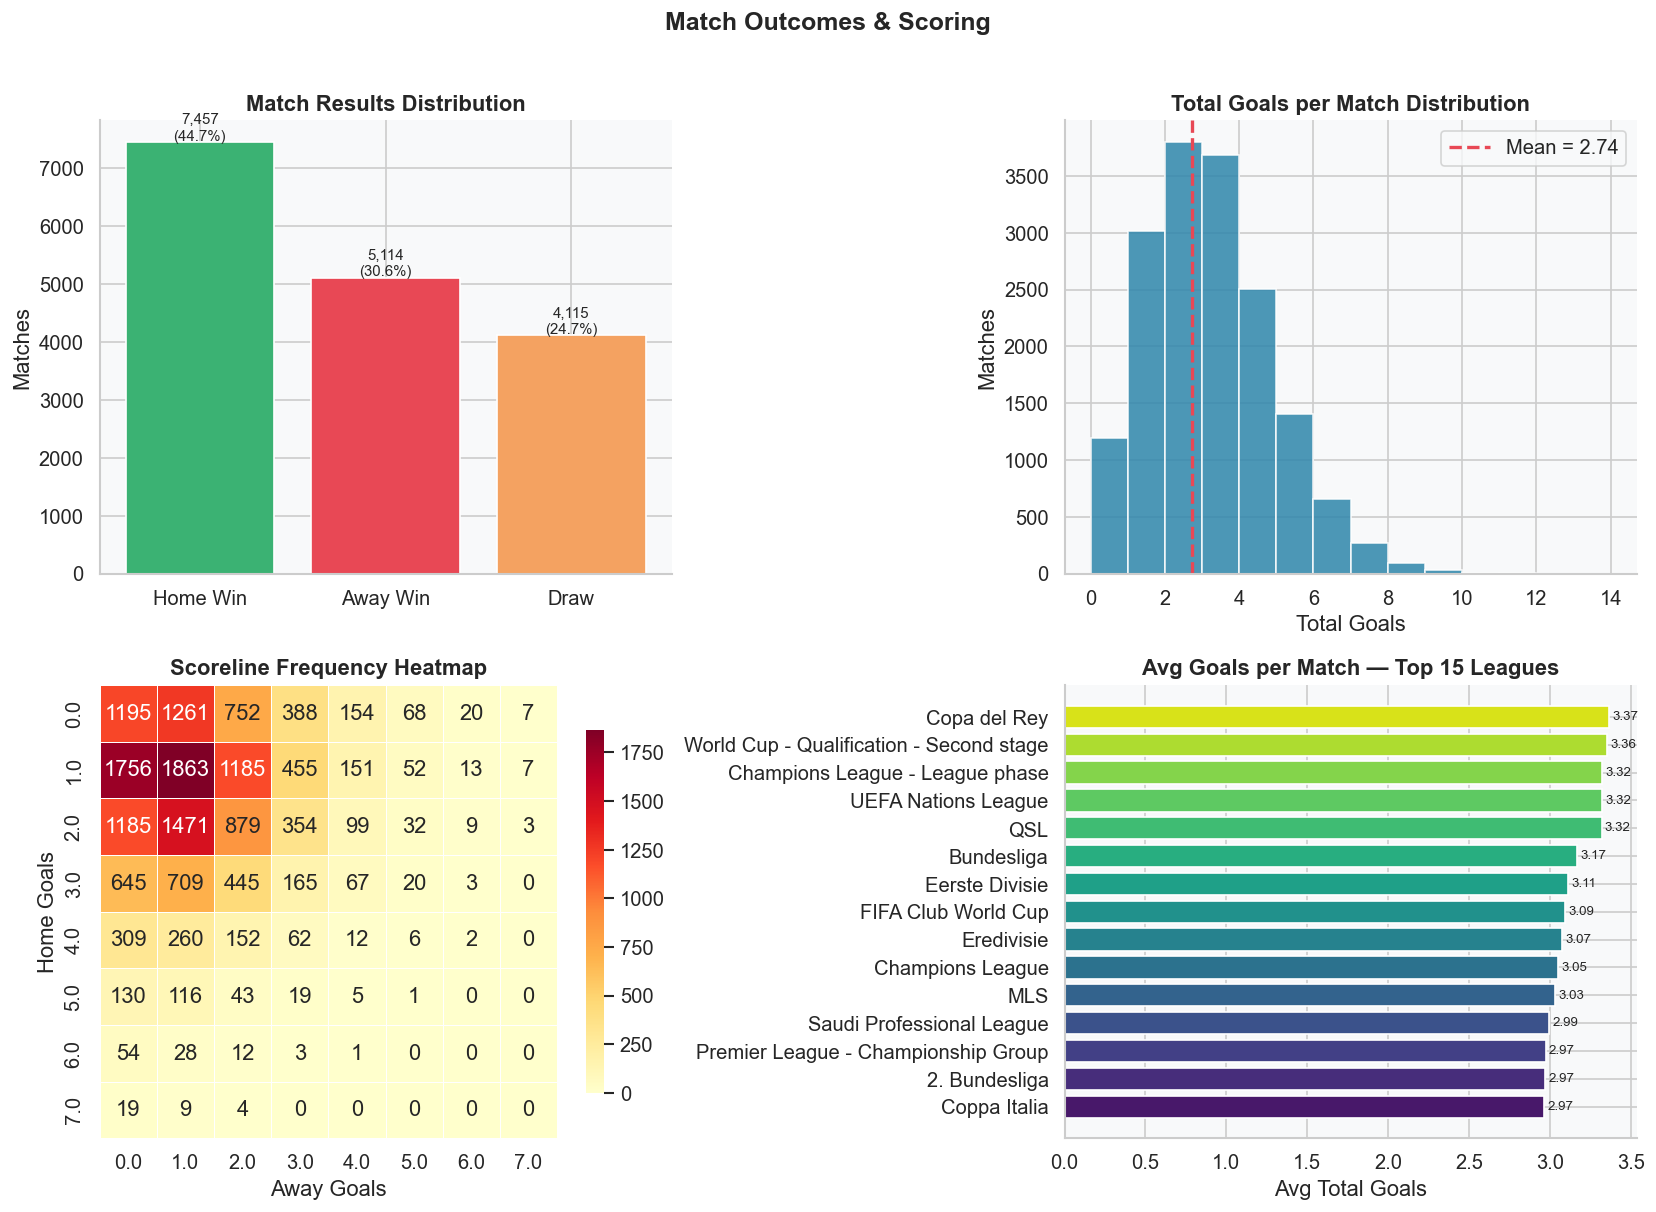

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['total_goals']   = df['home_goals'] + df['away_goals']

# ── Result distribution ──────────────────────────────────────
ax = axes[0, 0]
result_counts = df['result'].value_counts()
result_labels = {'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'}
colors_res = [ACCENT3, ACCENT2, '#F4A261']
bars = ax.bar([result_labels.get(k, k) for k in result_counts.index],
              result_counts.values, color=colors_res, edgecolor='white')
for bar, val in zip(bars, result_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Match Results Distribution', fontweight='bold')
ax.set_ylabel('Matches')

# ── Goals per match histogram ────────────────────────────────
ax = axes[0, 1]
ax.hist(df['total_goals'], bins=range(0, 15), color=ACCENT, edgecolor='white', alpha=0.85)
ax.axvline(df['total_goals'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {df["total_goals"].mean():.2f}')
ax.set_title('Total Goals per Match Distribution', fontweight='bold')
ax.set_xlabel('Total Goals')
ax.set_ylabel('Matches')
ax.legend()

# ── Score heatmap (top scorelines) ──────────────────────────
ax = axes[1, 0]
score_pivot = df.groupby(['home_goals','away_goals']).size().unstack(fill_value=0)
score_pivot = score_pivot.loc[
    score_pivot.index[score_pivot.index <= 7],
    score_pivot.columns[score_pivot.columns <= 7]
]
sns.heatmap(score_pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Scoreline Frequency Heatmap', fontweight='bold')
ax.set_xlabel('Away Goals')
ax.set_ylabel('Home Goals')

# ── Goals per match by league ────────────────────────────────
ax = axes[1, 1]
league_goals = (df.groupby('league_division')['total_goals']
                  .mean().sort_values(ascending=False).head(15))
bars = ax.barh(league_goals.index[::-1], league_goals.values[::-1],
               color=sns.color_palette('viridis', len(league_goals)))
for bar, val in zip(bars, league_goals.values[::-1]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)
ax.set_title('Avg Goals per Match — Top 15 Leagues', fontweight='bold')
ax.set_xlabel('Avg Total Goals')

plt.suptitle('Match Outcomes & Scoring', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Home Advantage Analysis <a id='6-home'></a>

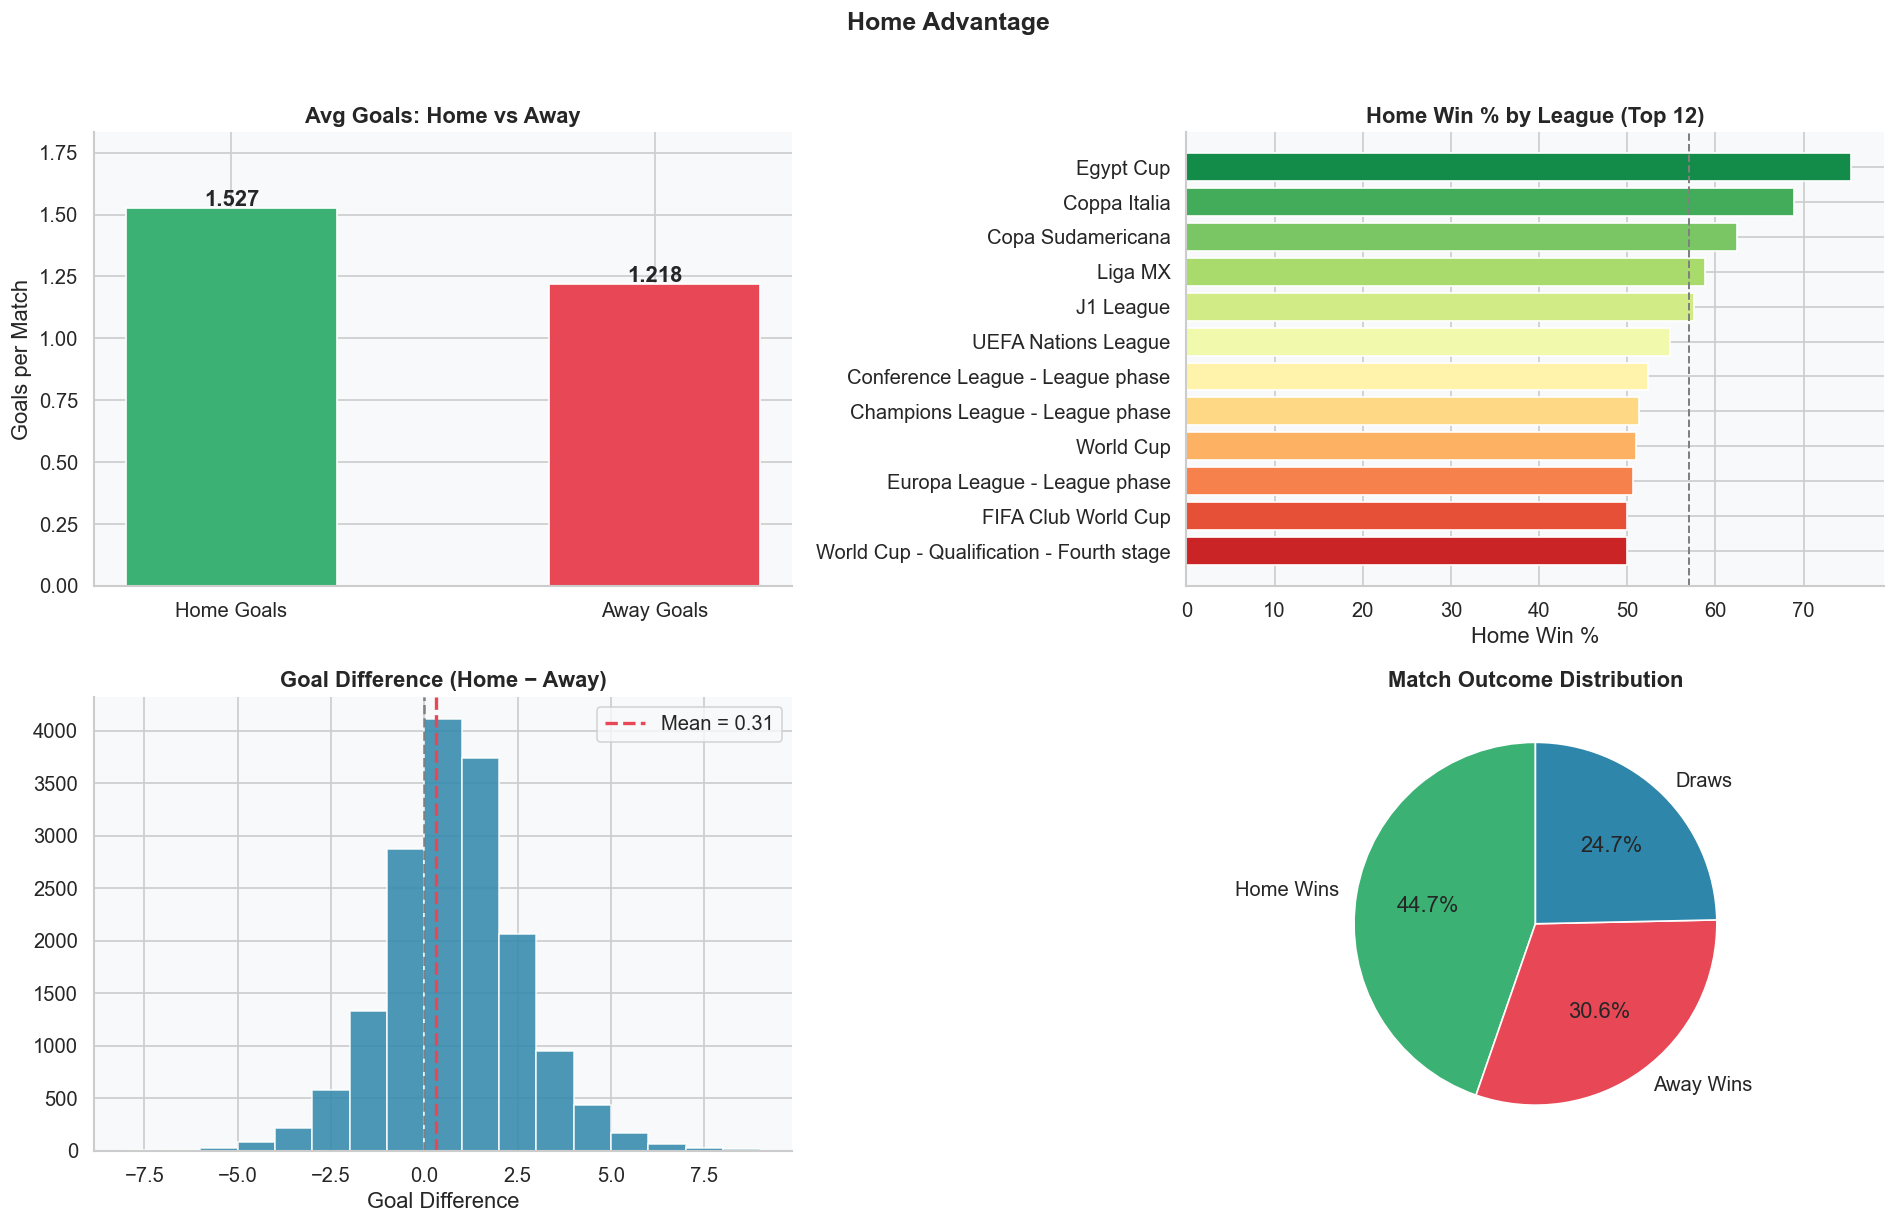

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
df['goal_diff'] = df['home_goals'] - df['away_goals']

# Flatten axes for easier indexing
axes = axes.flatten()

# (0) Avg Home vs Away Goals
ax = axes[0]
means = {'Home Goals': df['home_goals'].mean(), 'Away Goals': df['away_goals'].mean()}

bars = ax.bar(means.keys(), means.values(),
              color=[ACCENT3, ACCENT2], edgecolor='white', width=0.5)

for bar, val in zip(bars, means.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontweight='bold')

ax.set_ylim(0, max(means.values()) * 1.2)
ax.set_title('Avg Goals: Home vs Away', fontweight='bold')
ax.set_ylabel('Goals per Match')

# (1) Home Win % by League
ax = axes[1]
home_win_rate = (df.groupby('league_division')['result']
                   .apply(lambda x: (x == 'H').mean() * 100)
                   .sort_values(ascending=False).head(12))

colors_hw = sns.color_palette('RdYlGn', len(home_win_rate))

ax.barh(home_win_rate.index[::-1],
        home_win_rate.values[::-1],
        color=colors_hw)

ax.axvline(home_win_rate.mean(), color='gray', linestyle='--', linewidth=1.2)

ax.set_title('Home Win % by League (Top 12)', fontweight='bold')
ax.set_xlabel('Home Win %')

# (2) Goal Difference Distribution
ax = axes[2]

ax.hist(df['goal_diff'], bins=range(-8, 10),
        color=ACCENT, edgecolor='white', alpha=0.85)

ax.axvline(0, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(df['goal_diff'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {df["goal_diff"].mean():.2f}')

ax.set_title('Goal Difference (Home − Away)', fontweight='bold')
ax.set_xlabel('Goal Difference')
ax.legend()

# (3) Match Outcome Distribution (Pie)
ax = axes[3]

total = len(df)
hw = (df['result'] == 'H').sum()
aw = (df['result'] == 'A').sum()
drw = (df['result'] == 'D').sum()

sizes = [hw, aw, drw]
labels = ['Home Wins', 'Away Wins', 'Draws']
colors = [ACCENT3, ACCENT2, ACCENT]

ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

ax.set_title('Match Outcome Distribution', fontweight='bold')

# Global title
plt.suptitle('Home Advantage', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## 7. Shooting & Expected Goals (xG) Analysis <a id='7-xg'></a>

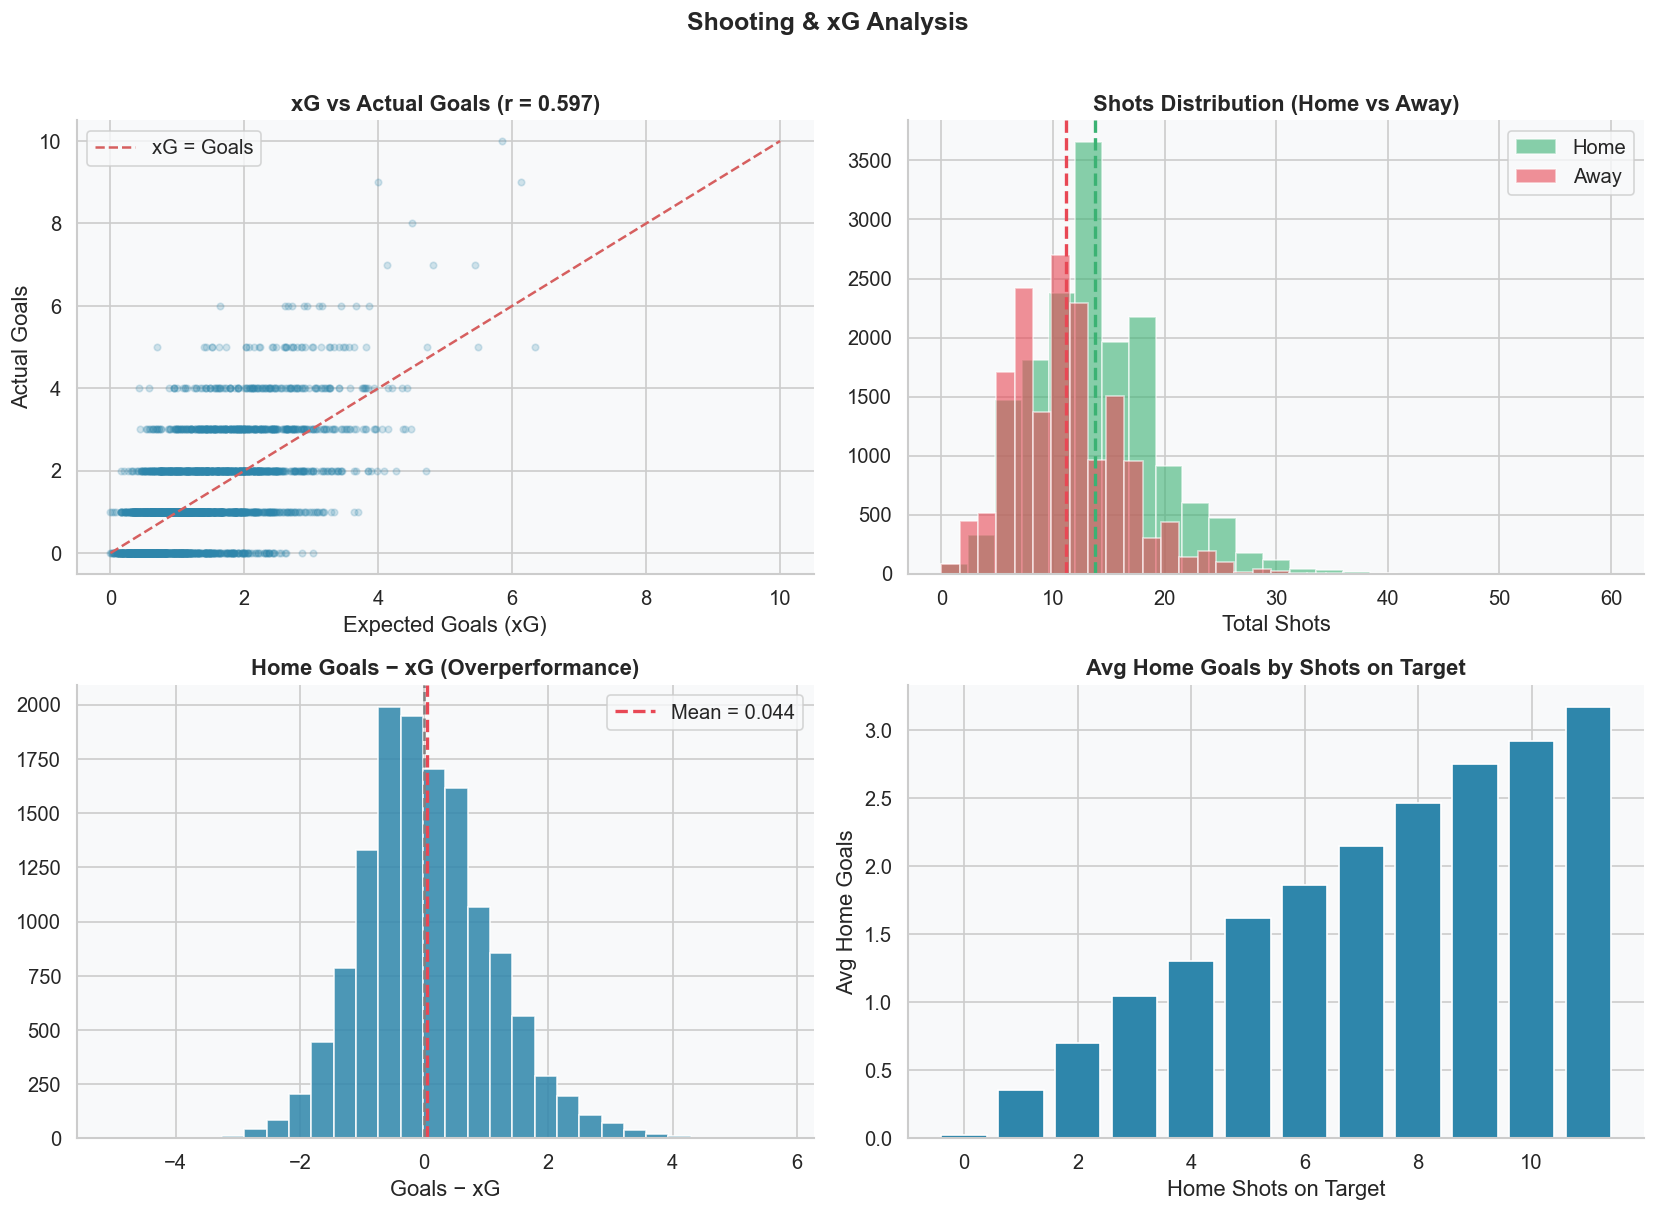

In [ ]:
xg_df = df.dropna(subset=['home_xg','away_xg','home_goals','away_goals'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# xG vs Actual Goals scatter
ax = axes[0, 0]
all_xg   = pd.concat([xg_df['home_xg'], xg_df['away_xg']]).reset_index(drop=True)
all_goals = pd.concat([xg_df['home_goals'], xg_df['away_goals']]).reset_index(drop=True)
sample = pd.DataFrame({'xg': all_xg, 'goals': all_goals}).sample(min(3000, len(all_xg)), random_state=42)
ax.scatter(sample['xg'], sample['goals'], alpha=0.2, color=ACCENT, s=15)
# perfect line
lims = [0, max(sample['xg'].max(), sample['goals'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='xG = Goals')
corr = sample.corr().loc['xg','goals']
ax.set_title(f'xG vs Actual Goals (r = {corr:.3f})', fontweight='bold')
ax.set_xlabel('Expected Goals (xG)')
ax.set_ylabel('Actual Goals')
ax.legend()

# Shots distribution
ax = axes[0, 1]
shots_df = df.dropna(subset=['home_shots_total','away_shots_total'])
ax.hist(shots_df['home_shots_total'], bins=25, alpha=0.6, label='Home', color=ACCENT3)
ax.hist(shots_df['away_shots_total'], bins=25, alpha=0.6, label='Away', color=ACCENT2)
ax.axvline(shots_df['home_shots_total'].mean(), color=ACCENT3, linestyle='--', linewidth=2)
ax.axvline(shots_df['away_shots_total'].mean(), color=ACCENT2, linestyle='--', linewidth=2)
ax.set_title('Shots Distribution (Home vs Away)', fontweight='bold')
ax.set_xlabel('Total Shots')
ax.legend()

# xG overperformance
ax = axes[1, 0]
xg_df = xg_df.copy()
xg_df['home_xg_diff'] = xg_df['home_goals'] - xg_df['home_xg']
ax.hist(xg_df['home_xg_diff'], bins=30, color=ACCENT, edgecolor='white', alpha=0.85)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(xg_df['home_xg_diff'].mean(), color=ACCENT2, linestyle='--', linewidth=2,
           label=f'Mean = {xg_df["home_xg_diff"].mean():.3f}')
ax.set_title('Home Goals − xG (Overperformance)', fontweight='bold')
ax.set_xlabel('Goals − xG')
ax.legend()

# Shots on target vs Goals
ax = axes[1, 1]
sot = df.dropna(subset=['home_shots_on_target','home_goals'])
avg_goals_by_sot = sot.groupby('home_shots_on_target')['home_goals'].mean().head(12)
ax.bar(avg_goals_by_sot.index, avg_goals_by_sot.values, color=ACCENT, edgecolor='white')
ax.set_title('Avg Home Goals by Shots on Target', fontweight='bold')
ax.set_xlabel('Home Shots on Target')
ax.set_ylabel('Avg Home Goals')

plt.suptitle('Shooting & xG Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Possession & Passing Analysis <a id='8-possession'></a>

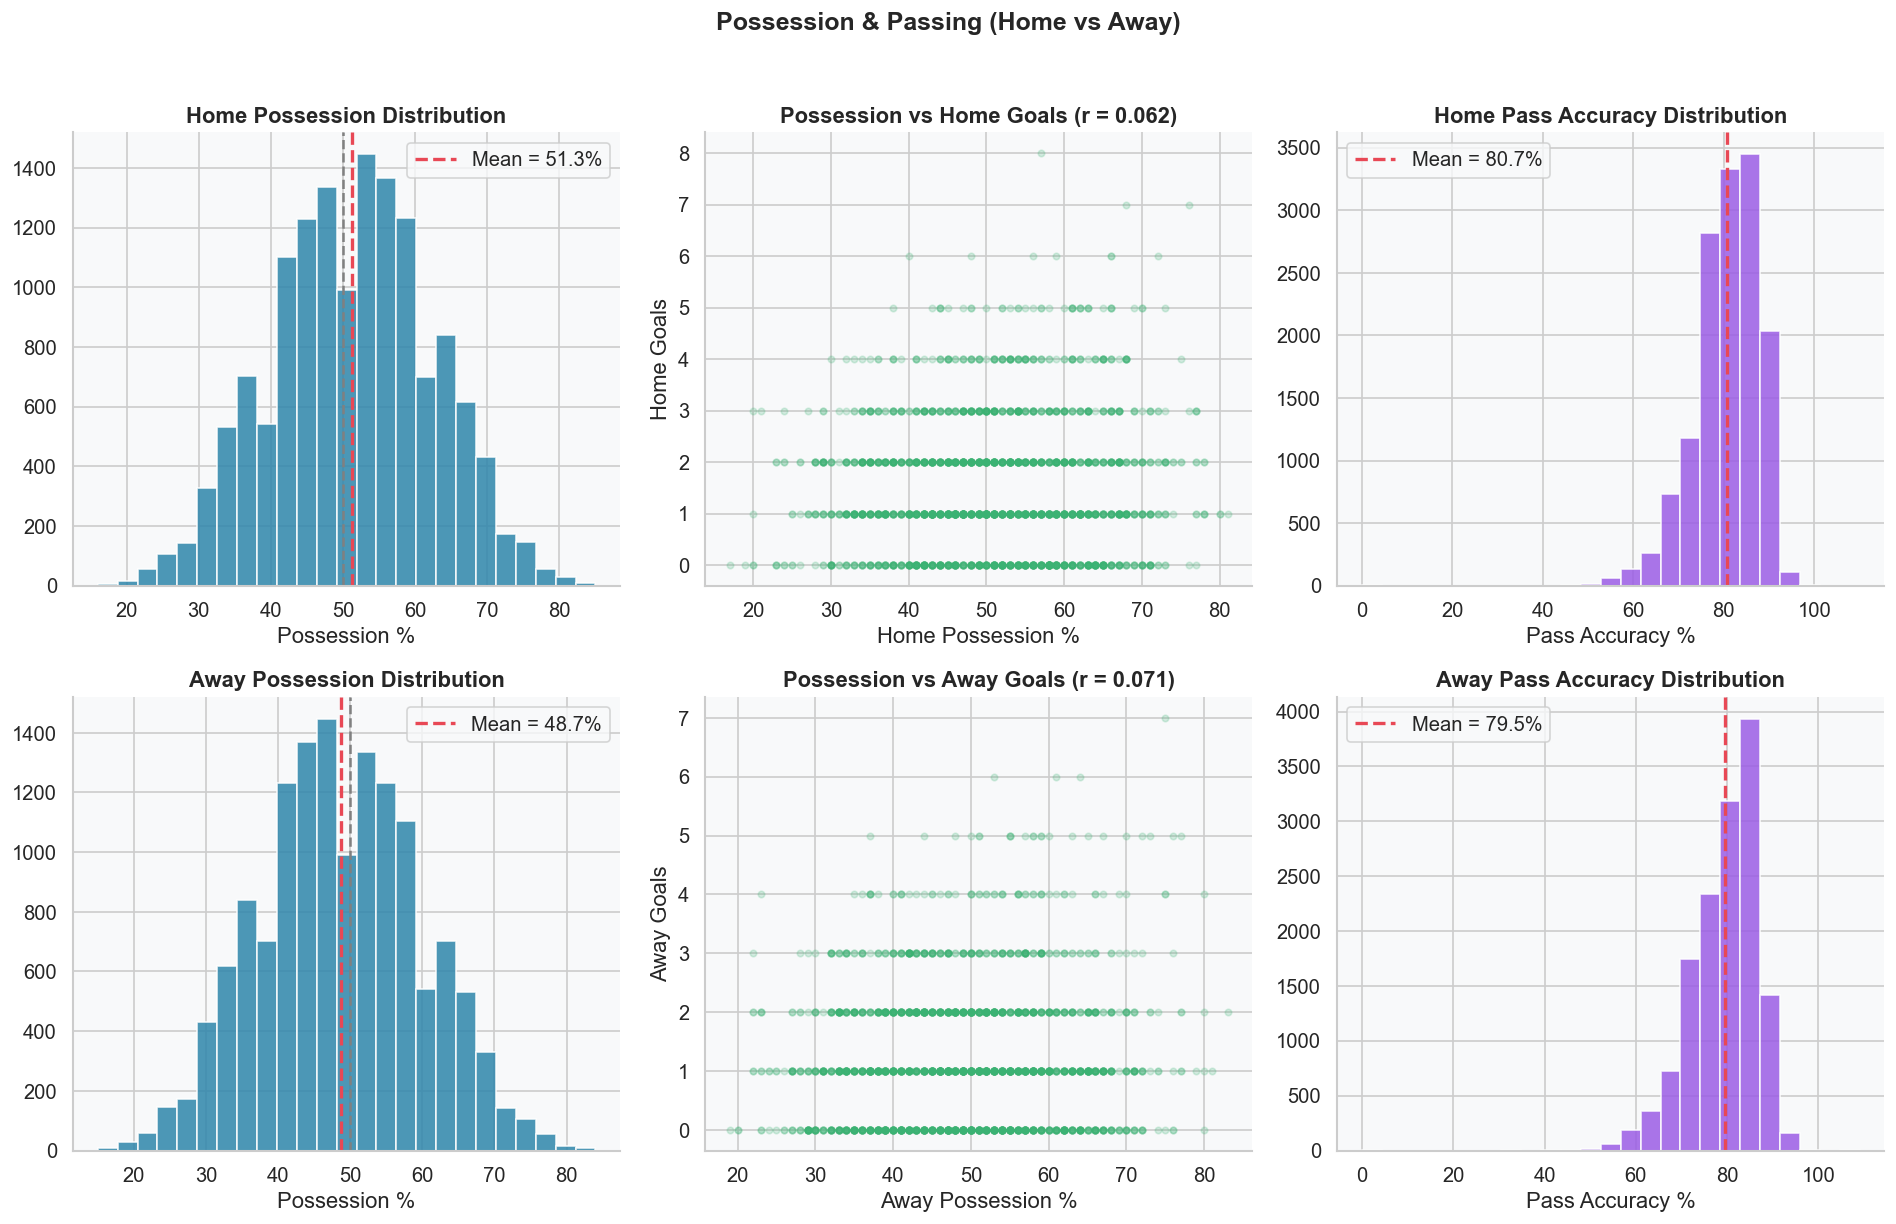

In [ ]:
poss_df = df.dropna(subset=['home_possession_pct','home_passes_pct'])
poss_df_away = df.dropna(subset=['away_possession_pct','away_passes_pct'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Possession distribution
ax = axes[0, 0]
ax.hist(poss_df['home_possession_pct'], bins=25, color=ACCENT, edgecolor='white', alpha=0.85)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(poss_df['home_possession_pct'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {poss_df["home_possession_pct"].mean():.1f}%')
ax.set_title('Home Possession Distribution', fontweight='bold')
ax.set_xlabel('Possession %')
ax.legend()

# Possession vs Goals scatter
ax = axes[0, 1]
sample2 = poss_df.sample(min(2000, len(poss_df)), random_state=1)
ax.scatter(sample2['home_possession_pct'], sample2['home_goals'],
           alpha=0.2, color=ACCENT3, s=15)

z = np.polyfit(sample2['home_possession_pct'], sample2['home_goals'], 1)
p = np.poly1d(z)
xs = np.linspace(sample2['home_possession_pct'].min(), sample2['home_possession_pct'].max(), 100)
ax.plot(xs, p(xs), color=ACCENT2, linewidth=2)

corr2 = sample2[['home_possession_pct','home_goals']].corr().iloc[0,1]
ax.set_title(f'Possession vs Home Goals (r = {corr2:.3f})', fontweight='bold')
ax.set_xlabel('Home Possession %')
ax.set_ylabel('Home Goals')

# Pass accuracy distribution
ax = axes[0, 2]
ax.hist(poss_df['home_passes_pct'], bins=25, color='#9B5DE5', edgecolor='white', alpha=0.85)
ax.axvline(poss_df['home_passes_pct'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {poss_df["home_passes_pct"].mean():.1f}%')
ax.set_title('Home Pass Accuracy Distribution', fontweight='bold')
ax.set_xlabel('Pass Accuracy %')
ax.legend()

# Possession distribution (away)
ax = axes[1, 0]
ax.hist(poss_df_away['away_possession_pct'], bins=25, color=ACCENT, edgecolor='white', alpha=0.85)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.5)
ax.axvline(poss_df_away['away_possession_pct'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {poss_df_away["away_possession_pct"].mean():.1f}%')
ax.set_title('Away Possession Distribution', fontweight='bold')
ax.set_xlabel('Possession %')
ax.legend()

# Possession vs Goals scatter (away)
ax = axes[1, 1]
sample3 = poss_df_away.sample(min(2000, len(poss_df_away)), random_state=1)
ax.scatter(sample3['away_possession_pct'], sample3['away_goals'],
           alpha=0.2, color=ACCENT3, s=15)

z = np.polyfit(sample3['away_possession_pct'], sample3['away_goals'], 1)
p = np.poly1d(z)
xs = np.linspace(sample3['away_possession_pct'].min(), sample3['away_possession_pct'].max(), 100)
ax.plot(xs, p(xs), color=ACCENT2, linewidth=2)

corr3 = sample3[['away_possession_pct','away_goals']].corr().iloc[0,1]
ax.set_title(f'Possession vs Away Goals (r = {corr3:.3f})', fontweight='bold')
ax.set_xlabel('Away Possession %')
ax.set_ylabel('Away Goals')

# Pass accuracy distribution (away)
ax = axes[1, 2]
ax.hist(poss_df_away['away_passes_pct'], bins=25, color='#9B5DE5', edgecolor='white', alpha=0.85)
ax.axvline(poss_df_away['away_passes_pct'].mean(), color=ACCENT2, linestyle='--',
           linewidth=2, label=f'Mean = {poss_df_away["away_passes_pct"].mean():.1f}%')
ax.set_title('Away Pass Accuracy Distribution', fontweight='bold')
ax.set_xlabel('Pass Accuracy %')
ax.legend()


plt.suptitle('Possession & Passing (Home vs Away)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

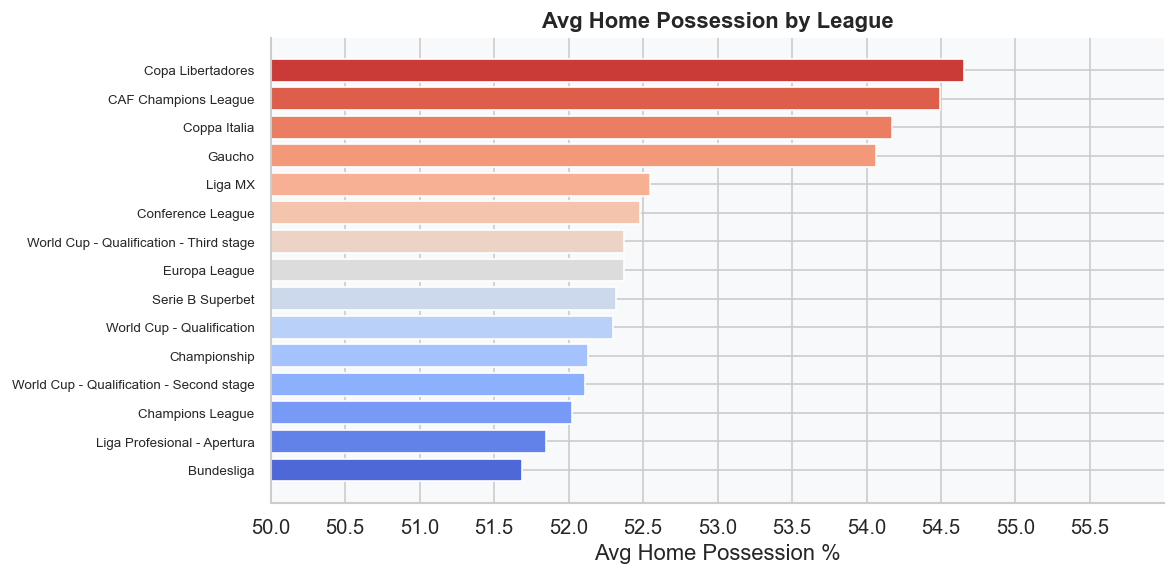

In [ ]:
global_mean = df['home_possession_pct'].mean()
alpha = 20  # strength of shrinkage
league_stats = df.groupby('league_division').agg(
    matches=('home_possession_pct', 'count'),
    avg_poss=('home_possession_pct', 'mean')
)
league_stats['smoothed_poss'] = (
    (league_stats['avg_poss'] * league_stats['matches'] +
     global_mean * alpha) /
    (league_stats['matches'] + alpha)
)
# Avg possession by league (NOW USING SMOOTHED VALUES)
league_poss = (
    league_stats[league_stats['matches'] >= 30]
    .sort_values('smoothed_poss', ascending=False)
    .head(15)['smoothed_poss']
)
fig, ax = plt.subplots(figsize=(10, 5))
colors_p = sns.color_palette('coolwarm', len(league_poss))
ax.barh(
    league_poss.index[::-1],
    league_poss.values[::-1],
    color=colors_p
)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Avg Home Possession by League', fontweight='bold')
ax.set_xlabel('Avg Home Possession %')
ax.set_xticks(np.arange(50, 56, 0.5))
ax.set_xlim(50, 56)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

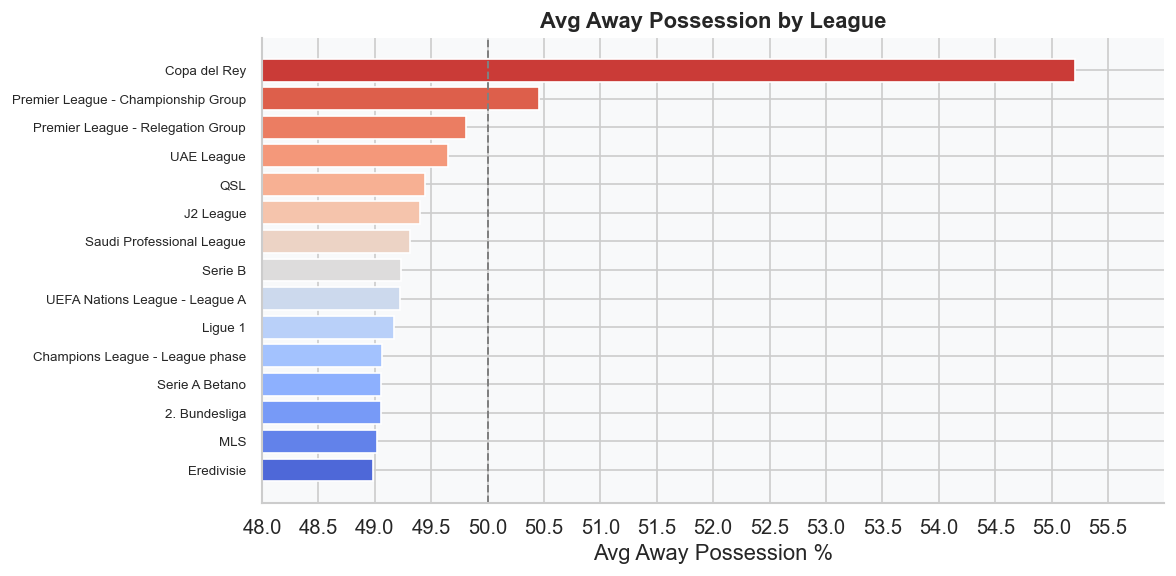

In [ ]:
global_mean = df['away_possession_pct'].mean()
alpha = 20  # strength of shrinkage
league_stats = df.groupby('league_division').agg(
    matches=('away_possession_pct', 'count'),
    avg_poss=('away_possession_pct', 'mean')
)
league_stats['smoothed_poss'] = (
    (league_stats['avg_poss'] * league_stats['matches'] +
     global_mean * alpha) /
    (league_stats['matches'] + alpha)
)
# Avg possession by league (NOW USING SMOOTHED VALUES)
league_poss = (
    league_stats[league_stats['matches'] >= 30]
    .sort_values('smoothed_poss', ascending=False)
    .head(15)['smoothed_poss']
)
fig, ax = plt.subplots(figsize=(10, 5))
colors_p = sns.color_palette('coolwarm', len(league_poss))
ax.barh(
    league_poss.index[::-1],
    league_poss.values[::-1],
    color=colors_p
)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.2)
ax.set_title('Avg Away Possession by League', fontweight='bold')
ax.set_xlabel('Avg Away Possession %')
ax.set_xticks(np.arange(48, 56, 0.5))
ax.set_xlim(48, 56)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## 9. Discipline — Cards & Fouls <a id='9-discipline'></a>

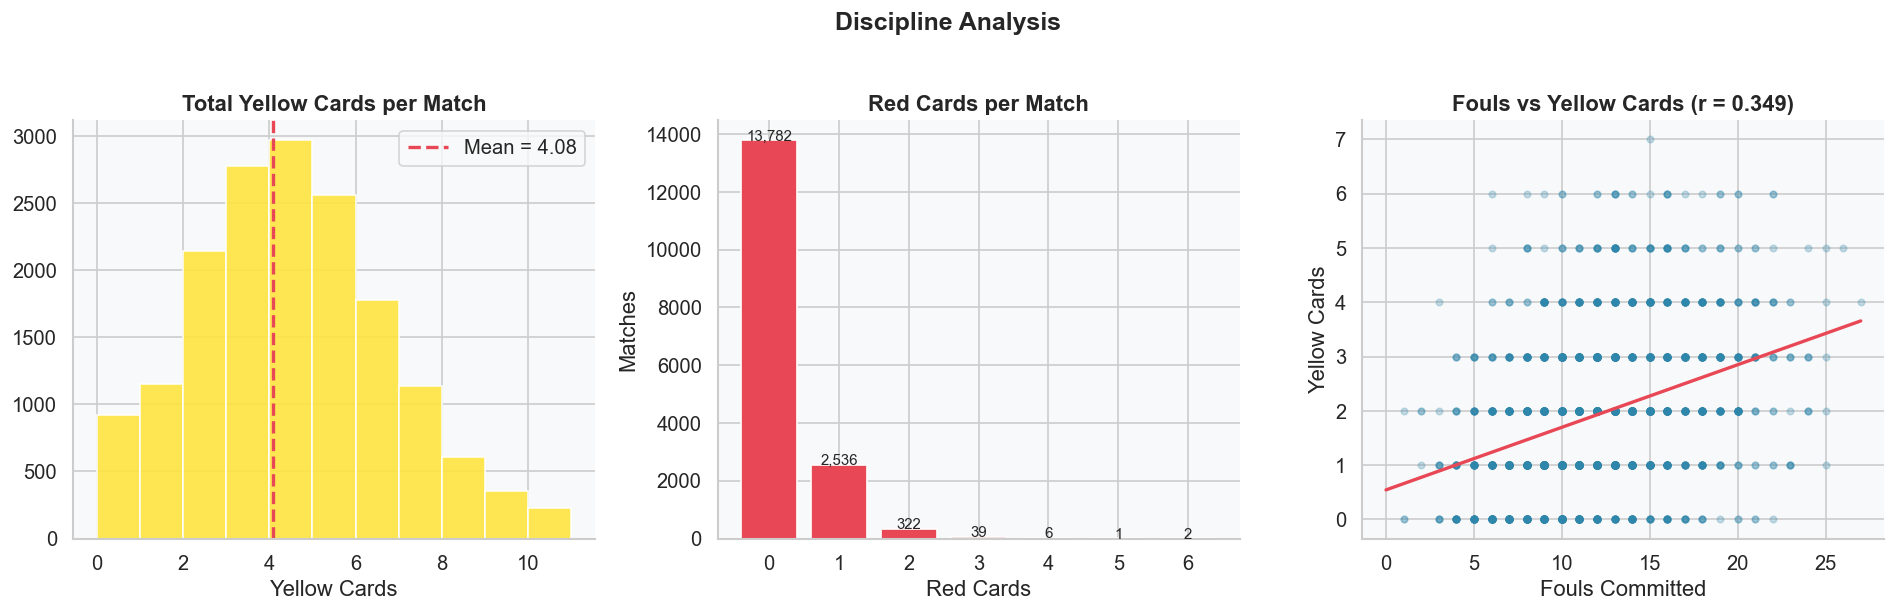

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Yellow cards distribution
ax = axes[0]
yc = df['home_yellow_cards'] + df['away_yellow_cards']
ax.hist(yc.dropna(), bins=range(0, 12), color='#FEE440', edgecolor='white', alpha=0.9)
ax.axvline(yc.mean(), color=ACCENT2, linestyle='--', linewidth=2,
           label=f'Mean = {yc.mean():.2f}')
ax.set_title('Total Yellow Cards per Match', fontweight='bold')
ax.set_xlabel('Yellow Cards')
ax.legend()

# Red cards
ax = axes[1]
rc = df['home_red_cards'] + df['away_red_cards']
rc_counts = rc.value_counts().sort_index()
ax.bar(rc_counts.index, rc_counts.values, color=ACCENT2, edgecolor='white')
ax.set_title('Red Cards per Match', fontweight='bold')
ax.set_xlabel('Red Cards')
ax.set_ylabel('Matches')
for x, y in zip(rc_counts.index, rc_counts.values):
    ax.text(x, y + 5, f'{y:,}', ha='center', fontsize=9)

# Fouls vs Yellow Cards
ax = axes[2]
foul_df = df.dropna(subset=['home_fouls_committed','home_yellow_cards'])
sample3 = foul_df.sample(min(2000, len(foul_df)), random_state=7)
ax.scatter(sample3['home_fouls_committed'], sample3['home_yellow_cards'],
           alpha=0.25, color=ACCENT, s=15)
z2 = np.polyfit(sample3['home_fouls_committed'], sample3['home_yellow_cards'], 1)
xs2 = np.linspace(0, sample3['home_fouls_committed'].max(), 100)
ax.plot(xs2, np.poly1d(z2)(xs2), color=ACCENT2, linewidth=2)
corr3 = sample3[['home_fouls_committed','home_yellow_cards']].corr().iloc[0,1]
ax.set_title(f'Fouls vs Yellow Cards (r = {corr3:.3f})', fontweight='bold')
ax.set_xlabel('Fouls Committed')
ax.set_ylabel('Yellow Cards')

plt.suptitle('Discipline Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Total Cards by League

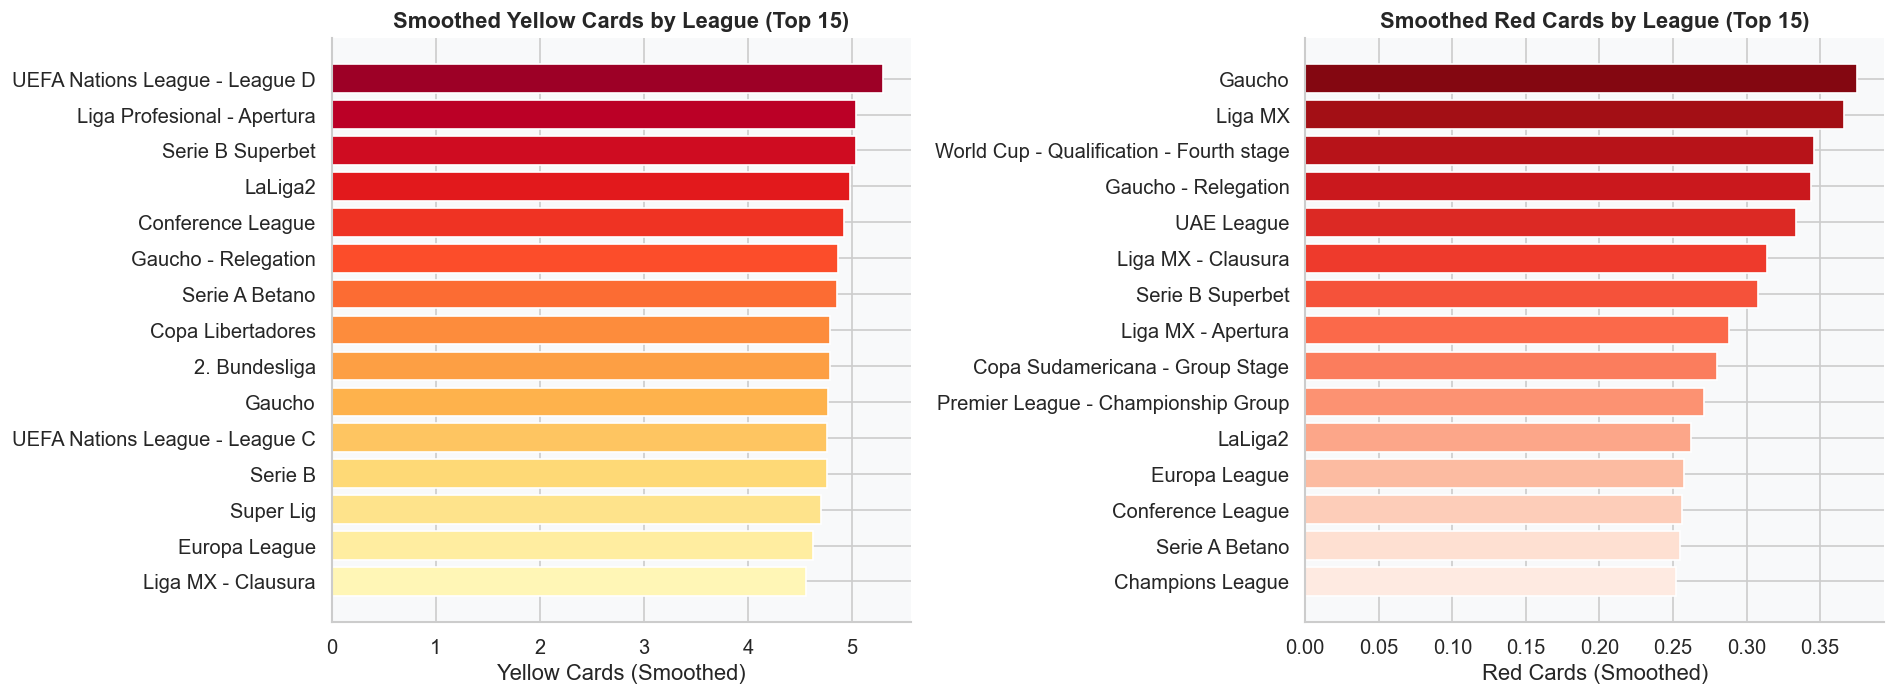

In [ ]:
league_cards = df.copy()

league_cards['total_yellow'] = league_cards['home_yellow_cards'] + league_cards['away_yellow_cards']
league_cards['total_red'] = league_cards['home_red_cards'] + league_cards['away_red_cards']

global_yc = league_cards['total_yellow'].mean()
global_rc = league_cards['total_red'].mean()

alpha = 20  # smoothing strength

league_stats = league_cards.groupby('league_division').agg(
    matches=('total_yellow', 'count'),
    yc_sum=('total_yellow', 'sum'),
    rc_sum=('total_red', 'sum')
)

# BAYESIAN SMOOTHING
league_stats['smoothed_yc'] = (
    (league_stats['yc_sum'] + alpha * global_yc) /
    (league_stats['matches'] + alpha)
)

league_stats['smoothed_rc'] = (
    (league_stats['rc_sum'] + alpha * global_rc) /
    (league_stats['matches'] + alpha)
)
yc = league_stats['smoothed_yc'].sort_values(ascending=False).head(15)
rc = league_stats['smoothed_rc'].sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# YELLOW CARDS
axes[0].barh(
    yc.index[::-1],
    yc.values[::-1],
    color=sns.color_palette('YlOrRd', len(yc))
)

axes[0].set_title('Smoothed Yellow Cards by League (Top 15)', fontweight='bold')
axes[0].set_xlabel('Yellow Cards (Smoothed)')

# RED CARDS
axes[1].barh(
    rc.index[::-1],
    rc.values[::-1],
    color=sns.color_palette('Reds', len(rc))
)

axes[1].set_title('Smoothed Red Cards by League (Top 15)', fontweight='bold')
axes[1].set_xlabel('Red Cards (Smoothed)')

plt.tight_layout()
plt.show()

## 10. Team Formations

In [ ]:
# Check formation columns
print("Home formations:")
print(df['home_formation'].head())
print("\nAway formations:")
print(df['away_formation'].head())
print("\nUnique home formations:", df['home_formation'].nunique())
print("Unique away formations:", df['away_formation'].nunique())

# Show each formation and its count
# print("\n=== Home Formation Counts ===")
# print(df['home_formation'].value_counts())

# print("\n=== Away Formation Counts ===")
# print(df['away_formation'].value_counts())

print("\n=== Combined Formation Counts (Home + Away) ===")
all_formations = pd.concat([df['home_formation'], df['away_formation']])
print(all_formations.value_counts())

Home formations:
0        NaN
1        NaN
2    4-2-3-1
3    4-2-3-1
4    4-2-3-1
Name: home_formation, dtype: str

Away formations:
0        NaN
1        NaN
2    4-2-3-1
3    4-2-3-1
4    4-4-1-1
Name: away_formation, dtype: str

Unique home formations: 29
Unique away formations: 31

=== Combined Formation Counts (Home + Away) ===
4-2-3-1    10130
4-3-3       6014
4-4-2       3978
3-4-2-1     2856
3-5-2       1937
4-1-4-1     1305
3-4-3       1289
5-3-2        985
5-4-1        760
3-4-1-2      743
4-5-1        277
4-3-1-2      276
3-1-4-2      274
3-3-2-2      244
4-4-1-1      240
3-5-1-1      183
4-1-2-3      178
4-3-2-1      177
4-2-1-3      153
4-1-3-2      148
4-1-2-1       73
3-3-1-3       64
4-2-2-2       54
3-2-4-1       23
5-2-3         15
3-3-3-1       11
5-3-1-1        6
4-2-4          5
3-2-3-2        4
2-3-2-3        1
5-2-2-1        1
Name: count, dtype: int64


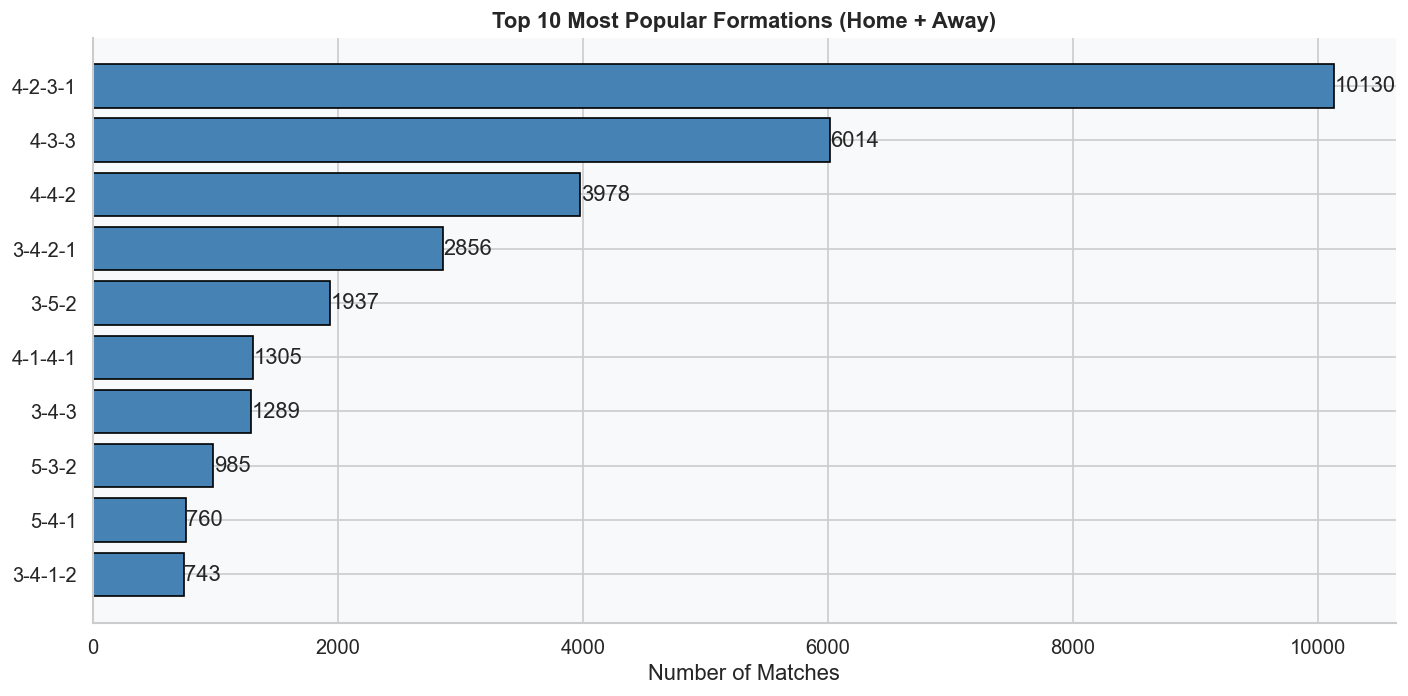

In [ ]:
# Combine both home and away formations
all_formations = pd.concat([df['home_formation'], df['away_formation']])

# Most frequently used formations
formation_counts = all_formations.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
top_10 = formation_counts.head(10)
ax.barh(top_10.index, top_10.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Matches')
ax.set_title('Top 10 Most Popular Formations (Home + Away)', fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(top_10.values):
    ax.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()


NameError: name 'formation_stats' is not defined

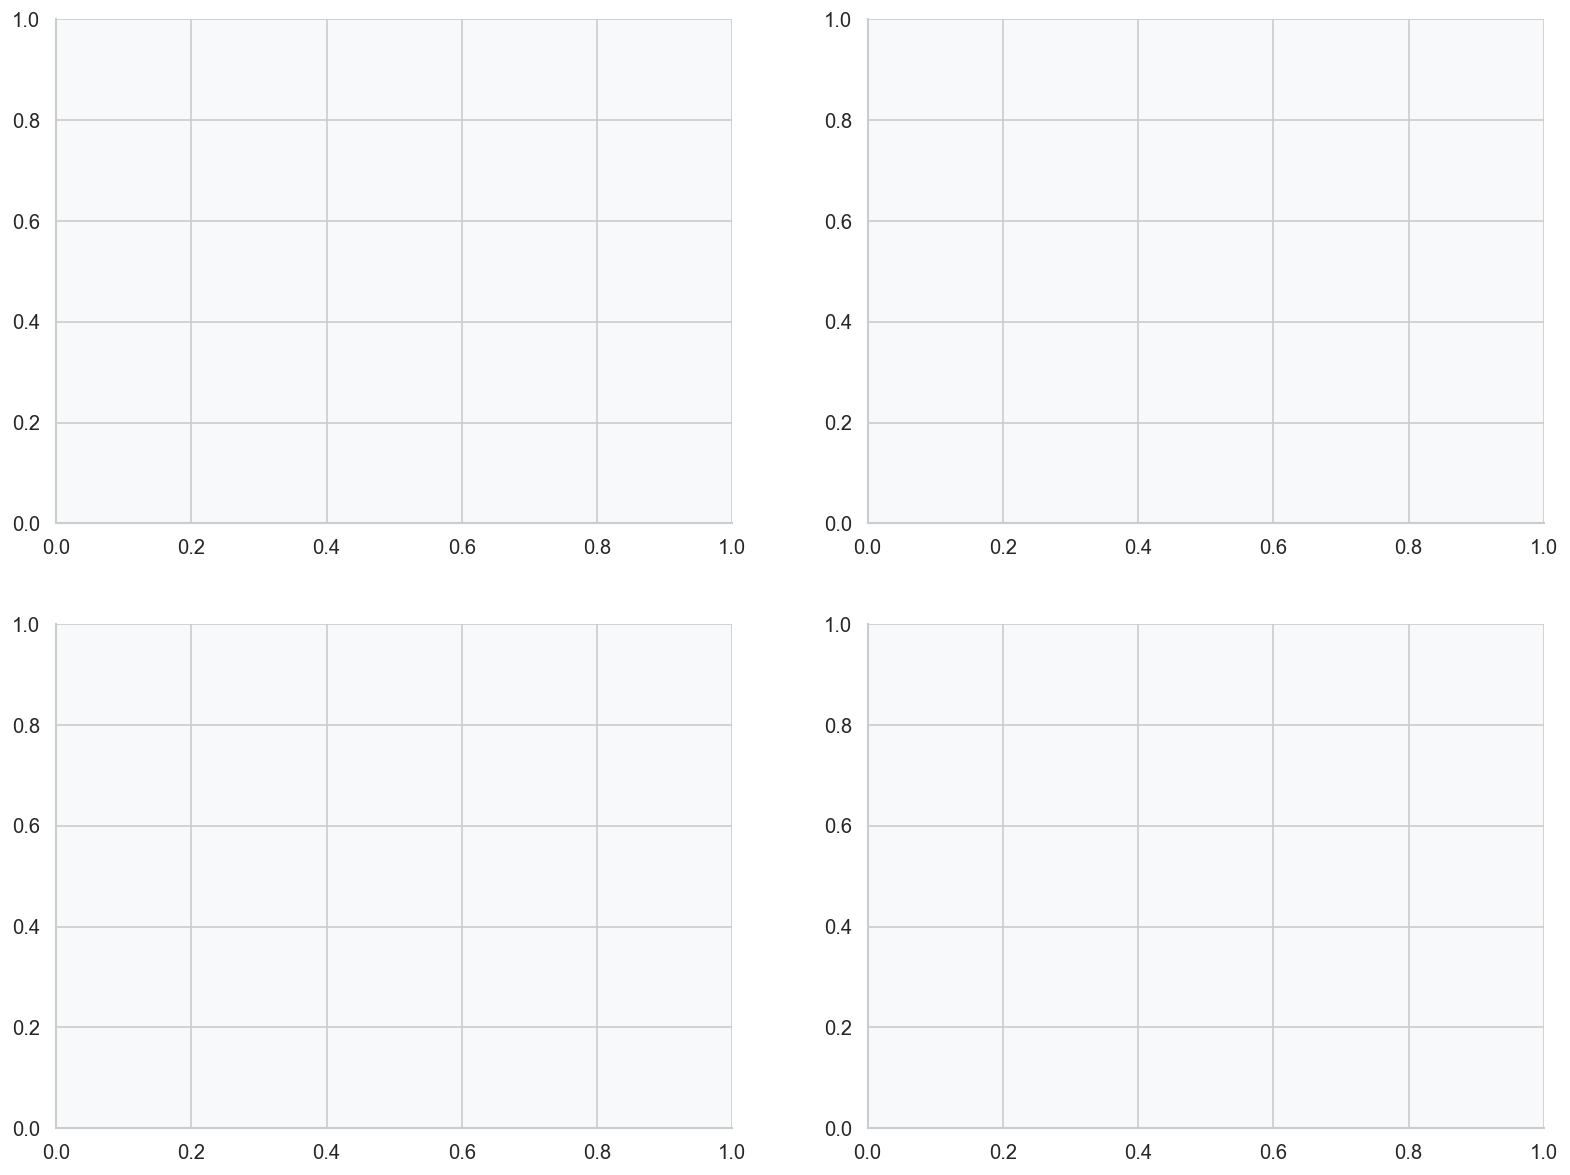

In [ ]:
# ── Build formation_stats and goals_stats ───────────────────────────────────
# Home formation stats
home_form = df.dropna(subset=['home_formation', 'result']).copy()
home_form['Win'] = (home_form['result'] == 'H').astype(int)
home_form['Total Goals'] = home_form['home_goals'] + home_form['away_goals']

home_agg = home_form.groupby('home_formation').agg(
    Matches=('home_formation', 'count'),
    Wins=('Win', 'sum'),
    Goals=('Total Goals', 'sum')
)

# Away formation stats
away_form = df.dropna(subset=['away_formation', 'result']).copy()
away_form['Win'] = (away_form['result'] == 'A').astype(int)
away_form['Total Goals'] = away_form['home_goals'] + away_form['away_goals']

away_agg = away_form.groupby('away_formation').agg(
    Matches=('away_formation', 'count'),
    Wins=('Win', 'sum'),
    Goals=('Total Goals', 'sum')
)

# Combine home + away into a single formation_stats DataFrame
formation_stats = (
    home_agg.add(away_agg, fill_value=0)
    .rename(columns={'Goals': 'Total Goals'})
    .astype({'Matches': int, 'Wins': int, 'Total Goals': int})
)

# goals_stats shares the same base; keep a separate copy for clarity
goals_stats = formation_stats[['Matches', 'Total Goals']].copy()

print(f'formation_stats built: {len(formation_stats)} formations')
print(formation_stats.sort_values('Matches', ascending=False).head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# (1) Formations: Total Matches vs Wins

# Top formations by number of wins
top_wins = formation_stats.sort_values('Wins', ascending=False).head(10)
# Sort for cleaner horizontal display
top_wins_sorted = top_wins.sort_values('Matches', ascending=True)
ax = axes[0]
# Background bars = total matches
ax.barh(
    top_wins_sorted.index,
    top_wins_sorted['Matches'],
    color='lightgray',
    edgecolor='none',
    label='Total Matches'
)
# Foreground bars = wins
ax.barh(
    top_wins_sorted.index,
    top_wins_sorted['Wins'],
    color='green',
    edgecolor='none',
    label='Wins'
)
ax.set_xlabel('Count')
ax.set_title(
    'Formations: Total Matches vs Wins',
    fontweight='bold'
)

ax.legend()

# (2) Smoothed Win %

global_win_rate = (
    formation_stats['Wins'].sum() /
    formation_stats['Matches'].sum()
)
alpha = 20  # smoothing strength
formation_stats['Smoothed Win %'] = (
    (
        formation_stats['Wins'] +
        alpha * global_win_rate
    ) /
    (
        formation_stats['Matches'] + alpha
    )
) * 100
# Minimum matches filter
top_win_pct = (
    formation_stats[formation_stats['Matches'] >= 700]
    .sort_values('Smoothed Win %', ascending=False)
    .head(10)
)
# Sort for cleaner display
top_pct_sorted = top_win_pct.sort_values(
    'Smoothed Win %',
    ascending=True
)
ax = axes[1]
ax.barh(
    top_pct_sorted.index,
    top_pct_sorted['Smoothed Win %'],
    color='darkorange',
    edgecolor='none'
)
ax.set_xlabel('Smoothed Win Percentage (%)')
ax.set_title(
    'Formations with Highest Smoothed Win % (min 700 matches)',
    fontweight='bold'
)

# (3) Formations with Most Total Goals

# Top formations by total goals
top_goals = goals_stats.sort_values(
    'Total Goals',
    ascending=False
).head(10)

# Sort for cleaner display
top_goals_sorted = top_goals.sort_values(
    'Total Goals',
    ascending=True
)
ax = axes[2]
# Total goals bars
ax.barh(
    top_goals_sorted.index,
    top_goals_sorted['Total Goals'],
    color='blue',
    edgecolor='none'
)
ax.set_xlabel('Total Goals')
ax.set_title(
    'Formations with Most Total Goals',
    fontweight='bold'
)

# (4) Smoothed Goals per Match
global_gpm = (
    goals_stats['Total Goals'].sum() /
    goals_stats['Matches'].sum()
)
alpha = 20  # smoothing strength
goals_stats['Smoothed Goals per Match'] = (
    (
        goals_stats['Total Goals'] +
        alpha * global_gpm
    ) /
    (
        goals_stats['Matches'] + alpha
    )
)
# Minimum matches filter
top_goals_per_match = (
    goals_stats[goals_stats['Matches'] >= 700]
    .sort_values(
        'Smoothed Goals per Match',
        ascending=False
    )
    .head(10)
)
# Sort for cleaner display
top_gpm_sorted = top_goals_per_match.sort_values(
    'Smoothed Goals per Match',
    ascending=True
)

ax = axes[3]
ax.barh(
    top_gpm_sorted.index,
    top_gpm_sorted['Smoothed Goals per Match'],
    color='purple',
    edgecolor='none'
)
ax.set_xlabel('Smoothed Goals per Match')
ax.set_title(
    'Formations with Highest Smoothed Goals/Match (min 700 matches)',
    fontweight='bold'
)

plt.suptitle(
    'Formation Performance Analysis',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## 11. Correlation Heatmap <a id='11-correlation'></a>

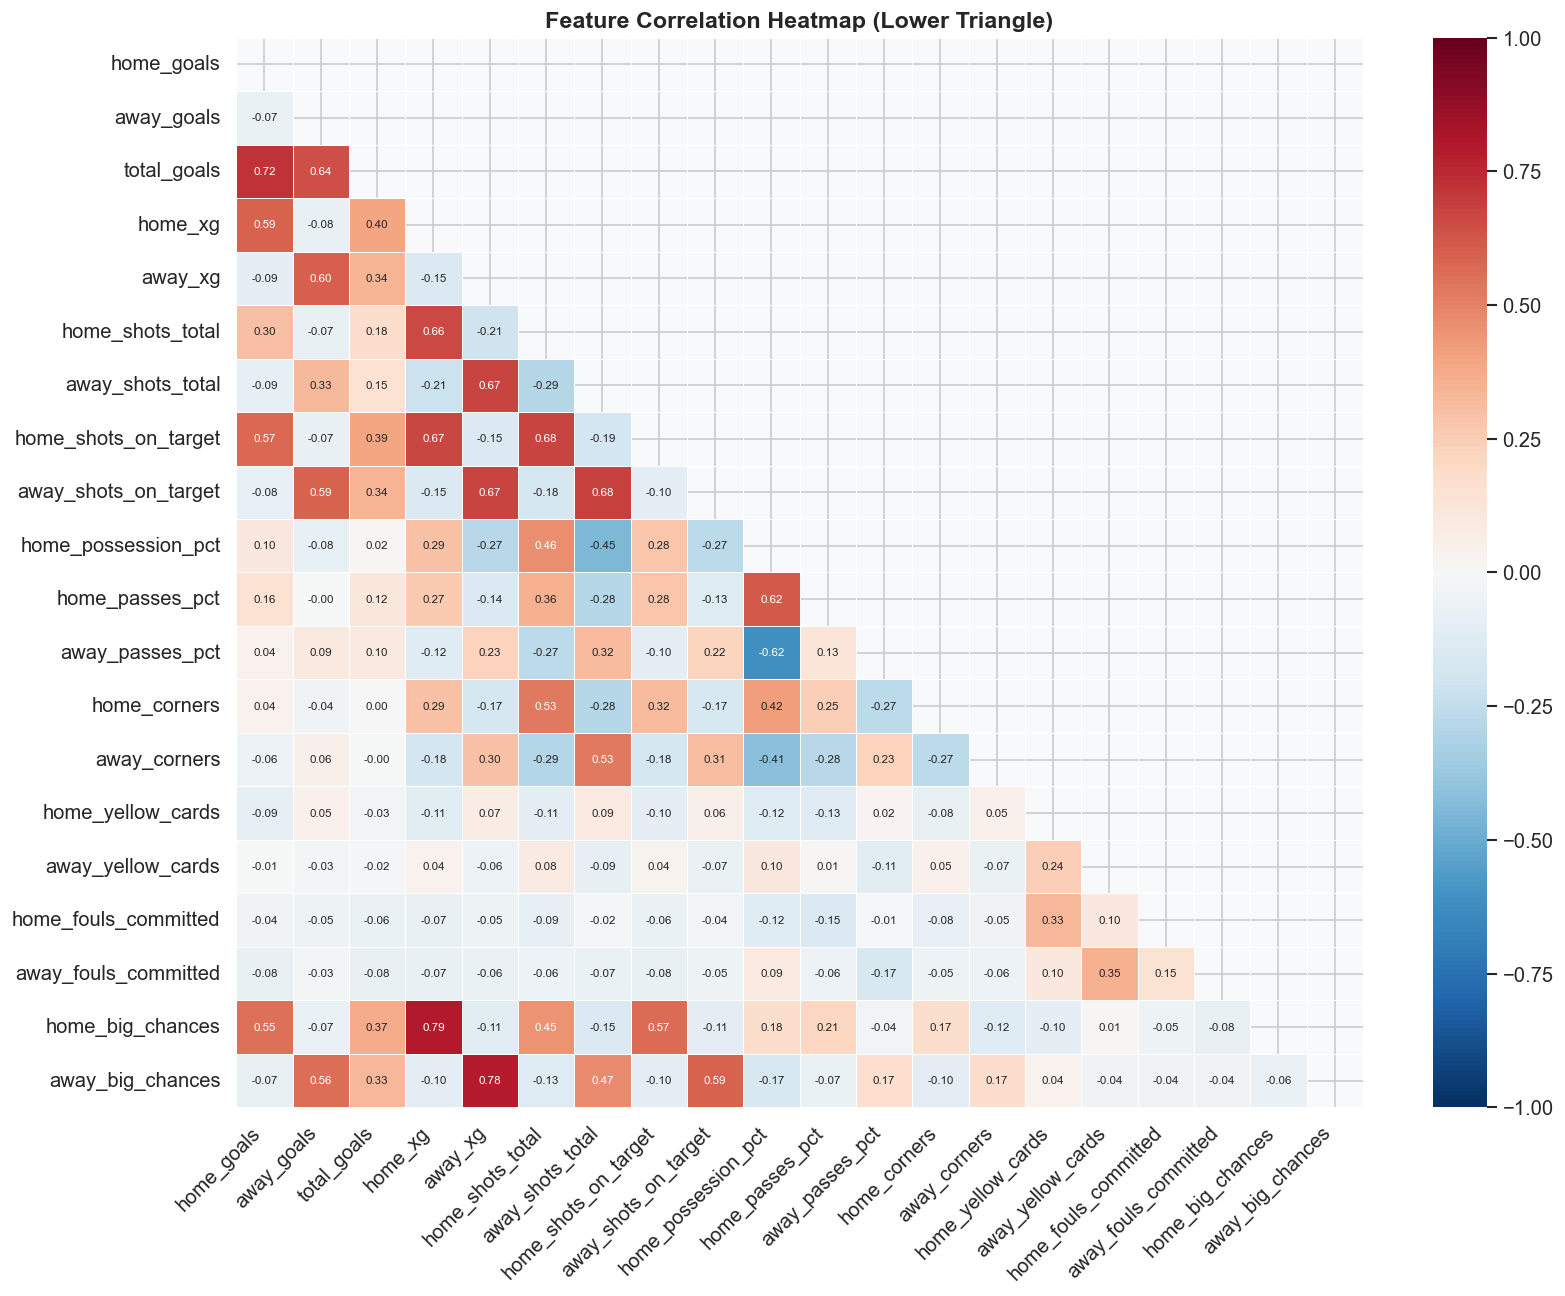

In [ ]:
corr_cols = [
    'home_goals','away_goals','total_goals',
    'home_xg','away_xg',
    'home_shots_total','away_shots_total',
    'home_shots_on_target','away_shots_on_target',
    'home_possession_pct',
    'home_passes_pct','away_passes_pct',
    'home_corners','away_corners',
    'home_yellow_cards','away_yellow_cards',
    'home_fouls_committed','away_fouls_committed',
    'home_big_chances','away_big_chances',
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Top Teams Analysis <a id='12-teams'></a>

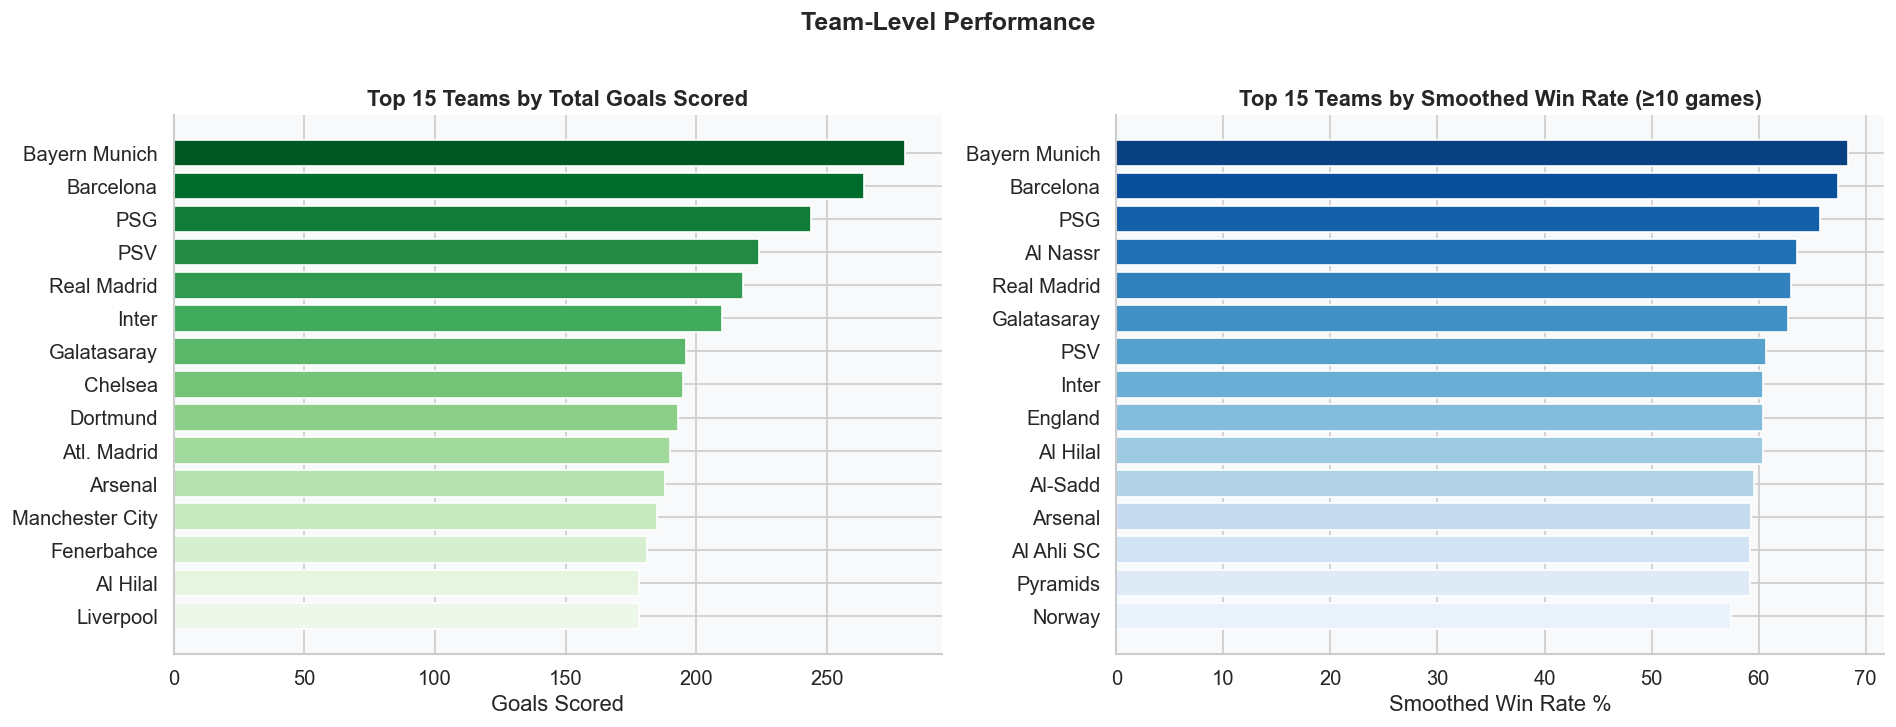

In [ ]:
# Build team-level stats
home_stats = df.groupby('home_team').agg(
    home_played=('match_id','count'),
    home_goals_scored=('home_goals','sum'),
    home_goals_conceded=('away_goals','sum'),
    home_wins=('result', lambda x: (x=='H').sum())
).reset_index().rename(columns={'home_team':'team'})

away_stats = df.groupby('away_team').agg(
    away_played=('match_id','count'),
    away_goals_scored=('away_goals','sum'),
    away_goals_conceded=('home_goals','sum'),
    away_wins=('result', lambda x: (x=='A').sum())
).reset_index().rename(columns={'away_team':'team'})

team_df = home_stats.merge(away_stats, on='team', how='outer').fillna(0)
team_df['total_played'] = team_df['home_played'] + team_df['away_played']
team_df['total_goals_scored'] = (
    team_df['home_goals_scored'] + team_df['away_goals_scored']
)
team_df['total_wins'] = (
    team_df['home_wins'] + team_df['away_wins']
)
team_df['win_rate'] = (
    team_df['total_wins'] / team_df['total_played'] * 100
)
team_df['avg_goals'] = (
    team_df['total_goals_scored'] / team_df['total_played']
)

global_win_rate = (
    team_df['total_wins'].sum() /
    team_df['total_played'].sum()
)

alpha = 20  # smoothing strength
team_df['smoothed_win_rate'] = (
    (
        team_df['total_wins'] +
        alpha * global_win_rate
    ) /
    (
        team_df['total_played'] + alpha
    )
) * 100

# Only teams with >=10 games
team_df = team_df[team_df['total_played'] >= 10]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Top scorers
ax = axes[0]

top_scorers = team_df.nlargest(15, 'total_goals_scored')

colors_s = sns.color_palette('Greens', 15)
ax.barh(
    top_scorers['team'][::-1],
    top_scorers['total_goals_scored'][::-1],
    color=colors_s
)
ax.set_title(
    'Top 15 Teams by Total Goals Scored',
    fontweight='bold'
)
ax.set_xlabel('Goals Scored')

# Top win rate
ax = axes[1]

# Bayesian-smoothed 
top_wr = team_df.nlargest(15, 'smoothed_win_rate')
colors_w = sns.color_palette('Blues', 15)
ax.barh(
    top_wr['team'][::-1],
    top_wr['smoothed_win_rate'][::-1],
    color=colors_w
)
ax.set_title(
    'Top 15 Teams by Smoothed Win Rate (≥10 games)',
    fontweight='bold'
)
ax.set_xlabel('Smoothed Win Rate %')
plt.suptitle(
    'Team-Level Performance',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

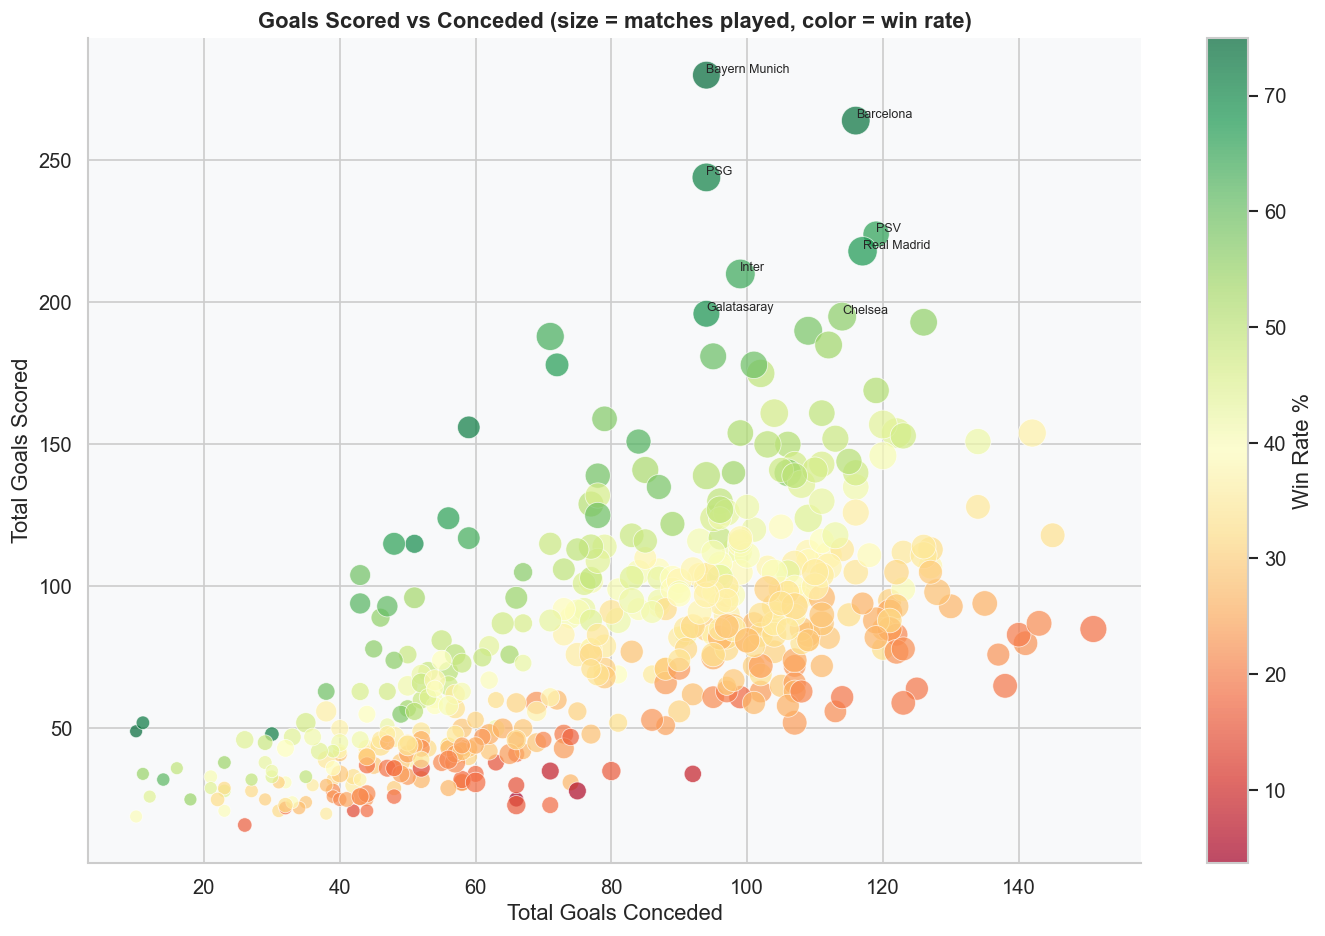

In [ ]:
# Goals scored vs conceded bubble chart
team_sub = team_df[team_df['total_played'] >= 20].copy()

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    team_sub['home_goals_conceded'] + team_sub['away_goals_conceded'],
    team_sub['total_goals_scored'],
    c=team_sub['win_rate'], cmap='RdYlGn',
    s=team_sub['total_played'] * 3,
    alpha=0.7, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, label='Win Rate %')
ax.set_xlabel('Total Goals Conceded')
ax.set_ylabel('Total Goals Scored')
ax.set_title('Goals Scored vs Conceded (size = matches played, color = win rate)', fontweight='bold')

# Annotate top teams
top_annot = team_sub.nlargest(8, 'total_goals_scored')
for _, row in top_annot.iterrows():
    ax.annotate(row['team'],
                xy=(row['home_goals_conceded']+row['away_goals_conceded'], row['total_goals_scored']),
                fontsize=7.5, ha='left', va='bottom')

plt.tight_layout()
plt.show()